# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import lime

C:\Users\Seif El Din Nassar\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Basic Data Exploratory

- Here we are just checking the different data sets, and seeing how they look in general

In [2]:
master = pd.read_csv('master_team_list.csv')

In [3]:
master.head()

,season,team,team_name
0,2016-17,1,Arsenal
1,2016-17,2,Bournemouth
2,2016-17,3,Burnley
3,2016-17,4,Chelsea
4,2016-17,5,Crystal Palace


In [4]:
master.count()

season       140
team         140
team_name    140
dtype: int64

In [5]:
fpl = pd.read_csv('cleaned_merged_seasons.csv')

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\2590381611.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  fpl = pd.read_csv('cleaned_merged_seasons.csv')


Here we notice that there are some null values, still we need some further exploration

In [6]:
fpl.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1.0,0.0,1,0,0,0,45,True,1,1


In [7]:
pd.set_option('display.max_columns', None)

In [8]:
fpl.tail()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
96164,2022-23,Oliver Skipp,MID,Spurs,0,0,16,0,0.0,441,377,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,11,Leeds,0,0,0,0,38,0,16761,4.0,1.0,0.0,2,100,742,642,43,False,0,38
96165,2022-23,Ryan Sessegnon,DEF,Spurs,0,0,0,0,0.0,436,377,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,11,Leeds,0,0,0,0,38,0,58774,4.0,1.0,0.0,0,-166,24,190,44,False,0,38
96166,2022-23,Ashley Young,DEF,Aston Villa,0,0,0,0,0.0,538,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,5,Brighton,0,0,0,0,38,0,96712,1.0,2.0,0.0,0,-1146,1522,2668,43,True,0,38
96167,2022-23,Jeremy Sarmiento Morante,MID,Brighton,0,0,0,0,0.0,119,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,2,Aston Villa,0,0,0,0,38,0,4511,1.0,2.0,0.0,0,-17,22,39,45,False,0,38
96168,2022-23,Philip Billing,MID,Bournemouth,0,0,15,0,0.0,70,376,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,8,Everton,0,0,0,0,38,0,98162,0.0,1.0,0.0,2,-18361,736,19097,50,False,0,38


Here we check to see what are the factors that are most corelated with the total points which is the thing that we would want to predict, so this helps us gain some more insights about the dataset <br>

- We notice that bps, influence and ict_index metrics have the most corelations, while something like redcards is negatively corelated because it decreases the total points

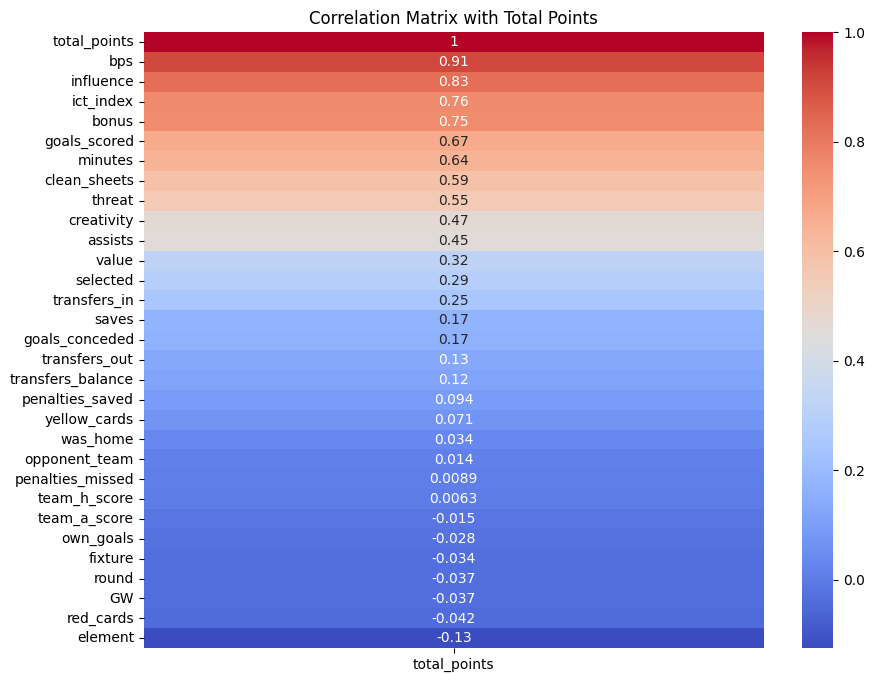

In [9]:
corr = fpl.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['total_points']].sort_values(by='total_points', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix with Total Points')
plt.show()

Here we check to see info about the data set and its column data types and so one, and again notice that team_x has many null values

In [10]:
fpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96169 entries, 0 to 96168
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season_x           96169 non-null  object 
 1   name               96169 non-null  object 
 2   position           96169 non-null  object 
 3   team_x             76317 non-null  object 
 4   assists            96169 non-null  int64  
 5   bonus              96169 non-null  int64  
 6   bps                96169 non-null  int64  
 7   clean_sheets       96169 non-null  int64  
 8   creativity         96169 non-null  float64
 9   element            96169 non-null  int64  
 10  fixture            96169 non-null  int64  
 11  goals_conceded     96169 non-null  int64  
 12  goals_scored       96169 non-null  int64  
 13  ict_index          96169 non-null  float64
 14  influence          96169 non-null  float64
 15  kickoff_time       96169 non-null  object 
 16  minutes            961

In [11]:
fpl.tail()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
96164,2022-23,Oliver Skipp,MID,Spurs,0,0,16,0,0.0,441,377,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,11,Leeds,0,0,0,0,38,0,16761,4.0,1.0,0.0,2,100,742,642,43,False,0,38
96165,2022-23,Ryan Sessegnon,DEF,Spurs,0,0,0,0,0.0,436,377,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,11,Leeds,0,0,0,0,38,0,58774,4.0,1.0,0.0,0,-166,24,190,44,False,0,38
96166,2022-23,Ashley Young,DEF,Aston Villa,0,0,0,0,0.0,538,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,5,Brighton,0,0,0,0,38,0,96712,1.0,2.0,0.0,0,-1146,1522,2668,43,True,0,38
96167,2022-23,Jeremy Sarmiento Morante,MID,Brighton,0,0,0,0,0.0,119,372,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,2,Aston Villa,0,0,0,0,38,0,4511,1.0,2.0,0.0,0,-17,22,39,45,False,0,38
96168,2022-23,Philip Billing,MID,Bournemouth,0,0,15,0,0.0,70,376,1,0,0.0,0.0,2023-05-28T15:30:00Z,90,8,Everton,0,0,0,0,38,0,98162,0.0,1.0,0.0,2,-18361,736,19097,50,False,0,38


Notes:

- There are 380 Fixtures in a premierleague season, that's why the max is 380

In [12]:
fpl.describe()

,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,GW
count,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,96169.000000,9.616900e+04,96169.000000,96169.000000,96169.000000,96169.000000,9.616900e+04,9.616900e+04,9.616900e+04,96169.000000,96169.000000,96169.000000
mean,0.041042,0.108715,6.080275,0.106739,4.734000,327.063264,198.413824,0.495887,0.045514,1.715793,7.146263,32.466117,10.505496,0.001633,0.001029,0.000717,0.001716,20.772099,0.101894,2.021442e+05,1.265158,1.516393,5.287598,1.379270,1.677100e+03,1.454716e+04,1.286945e+04,51.352390,0.053167,20.772099
std,0.215378,0.492334,9.850595,0.308783,10.689879,194.313766,108.884200,0.974269,0.233644,3.042551,12.873136,40.574888,5.764941,0.040629,0.032069,0.026776,0.041386,10.941742,0.650732,5.362493e+05,1.229086,1.349184,13.368420,2.542535,6.581628e+04,5.725343e+04,4.840128e+04,12.667432,0.224367,10.941742
min,0.000000,0.000000,-21.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-7.000000,-2.180978e+06,0.000000e+00,0.000000e+00,37.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,159.000000,105.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,5.457000e+03,0.000000,1.000000,0.000000,0.000000,-1.374000e+03,4.600000e+01,1.280000e+02,44.000000,0.000000,11.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,318.000000,203.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,22.000000,0.000000,2.763900e+04,1.000000,1.000000,0.000000,0.000000,-5.800000e+01,4.380000e+02,1.104000e+03,48.000000,0.000000,22.000000
75%,0.000000,0.000000,10.000000,0.000000,2.400000,486.000000,293.000000,1.000000,0.000000,2.500000,10.600000,90.000000,16.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,1.456790e+05,2.000000,2.000000,2.000000,2.000000,7.900000e+01,5.042000e+03,7.562000e+03,54.000000,0.000000,30.000000
max,4.000000,3.000000,128.000000,1.000000,170.900000,778.000000,380.000000,9.000000,4.000000,32.800000,163.600000,90.000000,20.000000,2.000000,1.000000,1.000000,1.000000,38.000000,14.000000,9.582624e+06,7.000000,9.000000,186.000000,29.000000,1.983733e+06,2.104464e+06,2.233619e+06,133.000000,1.000000,38.000000


In [13]:
fpl.describe(include=['object'])

,season_x,name,position,team_x,kickoff_time,opp_team_name
count,96169,96169,96169,76317,96169,96169
unique,5,1327,5,25,1220,31
top,2022-23,Ben Davies,MID,Everton,2023-05-28T15:30:00Z,Crystal Palace
freq,26505,283,39163,4079,778,4818


Checking to see how many players play more than one match in a season

Element is id of player throughout the season, some names are duplicates but not same person <br>
a triple gameweek was played in 21
there is a player that played that have same name but in different teams, this explains the person that played 4 matches in 1 gw

In [14]:
duplicate_players = fpl[fpl.duplicated(subset=['name', 'GW'], keep=False)]
duplicates_summary = duplicate_players.groupby(['name', 'GW', 'season_x']).size().reset_index(name='count')
duplicates_summary = duplicates_summary[duplicates_summary['count'] > 1]
duplicates_summary.describe()

,GW,count
count,5860.000000,5860.000000
mean,29.094198,2.009215
std,5.884796,0.102455
min,1.000000,2.000000
25%,25.000000,2.000000
50%,29.000000,2.000000
75%,35.000000,2.000000
max,38.000000,4.000000


In [15]:
duplicates_summary.head(20)

,name,GW,season_x,count
39,Aaron Connolly,22,2021-22,2
43,Aaron Connolly,25,2021-22,2
51,Aaron Connolly,29,2021-22,2
57,Aaron Connolly,33,2021-22,2
157,Aaron Cresswell,19,2020-21,2
167,Aaron Cresswell,21,2021-22,2
170,Aaron Cresswell,22,2017-18,2
207,Aaron Cresswell,29,2022-23,2
231,Aaron Cresswell,34,2022-23,2
243,Aaron Cresswell,37,2017-18,2


# Data Cleaning

## Handling Null Values

In [16]:
fpl.isnull().sum()

season_x                 0
name                     0
position                 0
team_x               19852
assists                  0
bonus                    0
bps                      0
clean_sheets             0
creativity               0
element                  0
fixture                  0
goals_conceded           0
goals_scored             0
ict_index                0
influence                0
kickoff_time             0
minutes                  0
opponent_team            0
opp_team_name            0
own_goals                0
penalties_missed         0
penalties_saved          0
red_cards                0
round                    0
saves                    0
selected                 0
team_a_score             0
team_h_score             0
threat                   0
total_points             0
transfers_balance        0
transfers_in             0
transfers_out            0
value                    0
was_home                 0
yellow_cards             0
GW                       0
d

<Axes: >

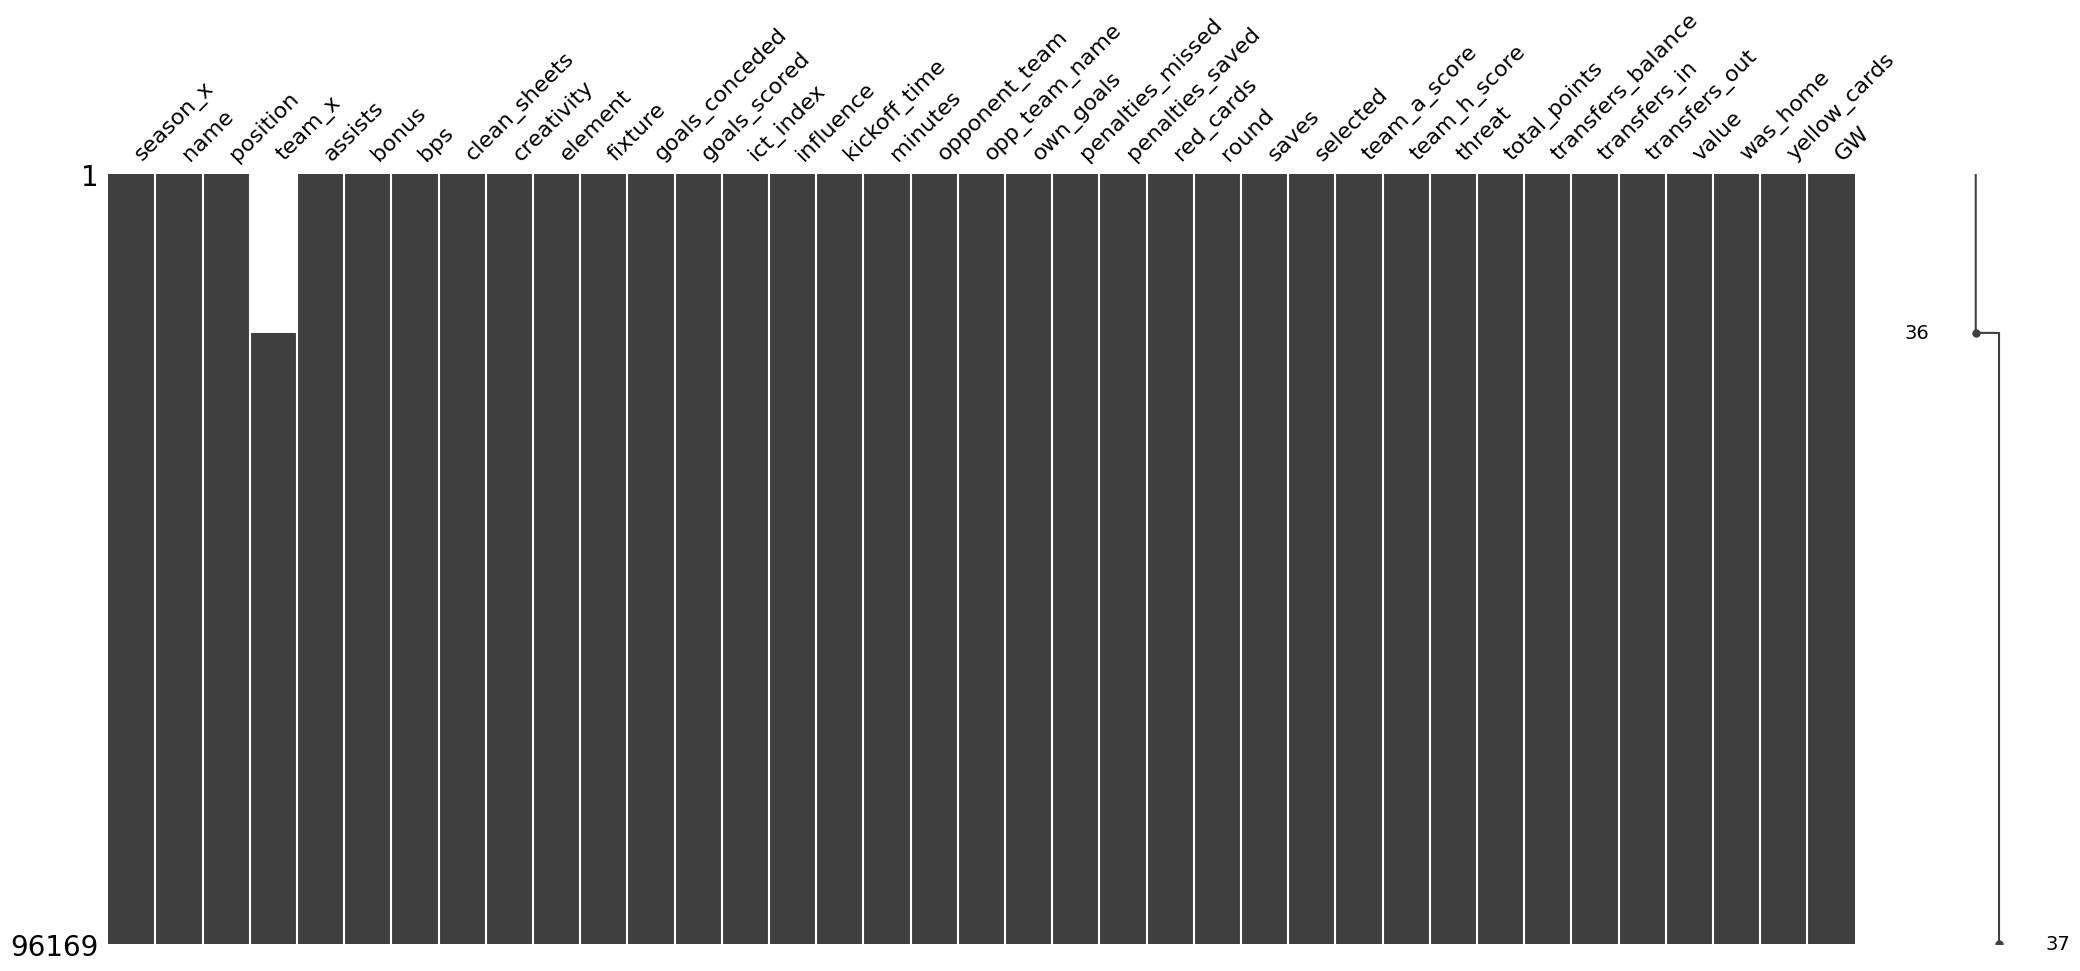

In [17]:
import missingno as msno
msno.matrix(fpl)

We think that season_x should be dropped since this information is encoded in the kickoff_time

In [18]:
fpl.groupby('season_x')['team_x'].apply(lambda x: x.isnull().sum())

season_x
2016-17     8567
2017-18    11285
2020-21        0
2021-22        0
2022-23        0
Name: team_x, dtype: int64

In [19]:
unique_players_1617 = fpl[fpl['season_x'] == '2016-17']['name'].unique()
unique_players_1718 = fpl[fpl['season_x'] == '2017-18']['name'].unique()

print("Unique players in 2016/17:", len(unique_players_1617))
print("Unique players in 2017/18:", len(unique_players_1718))

Unique players in 2016/17: 243
Unique players in 2017/18: 315


 We will proceed to fill in the missing names of the teams by the opponent name of the team that played in the same fixture

In [20]:
# Step 1 - Test, get two players who played in the same fixture for the same season
df_grouped = fpl.groupby(['season_x', 'fixture'])['opp_team_name'].unique().reset_index()
df_grouped['opp_team_name'] = df_grouped['opp_team_name'].apply(list)
df_grouped

,season_x,fixture,opp_team_name
0,2016-17,1,"[Swansea, Burnley]"
1,2016-17,2,"[West Brom, Crystal Palace]"
2,2016-17,3,"[Spurs, Everton]"
3,2016-17,4,"[Leicester, Hull]"
4,2016-17,5,"[Sunderland, Man City]"
...,...,...,...
1895,2022-23,376,"[Everton, Bournemouth]"
1896,2022-23,377,"[Spurs, Leeds]"
1897,2022-23,378,"[West Ham, Leicester]"
1898,2022-23,379,"[Man Utd, Fulham]"


In [21]:
fpl_copy = fpl.copy()

Here we are mapping the opponent team code to the team_x using teams that played in the same fixture

In [22]:
df_grouped = fpl.groupby(['season_x', 'fixture'])['opp_team_name'].unique().reset_index()
df_grouped['opp_team_name'] = df_grouped['opp_team_name'].apply(list)
def fill_team_x_vectorized(df, df_grouped):
    
    # Create a mapping from (season_x, fixture) to list of teams
    fixture_team_map = {(row['season_x'], row['fixture']): row['opp_team_name'] for _, row in df_grouped.iterrows()}
    
    # Only fill where team_x is null
    mask = df['team_x'].isnull()
    # Get all teams for each row's fixture
    all_teams = df.loc[mask].apply(lambda row: fixture_team_map.get((row['season_x'], row['fixture']), []), axis=1)
    # Find the other team
    other_team = [
        [t for t in teams if t != row['opp_team_name']][0] if len(teams) == 2 else np.nan
        for teams, (_, row) in zip(all_teams, df.loc[mask].iterrows())
    ]
    # Fill missing team_x
    df.loc[mask, 'team_x'] = other_team
    return df

fpl_copy = fill_team_x_vectorized(fpl_copy, df_grouped)

In [23]:
fpl_copy.isnull().sum()

season_x             0
name                 0
position             0
team_x               0
assists              0
bonus                0
bps                  0
clean_sheets         0
creativity           0
element              0
fixture              0
goals_conceded       0
goals_scored         0
ict_index            0
influence            0
kickoff_time         0
minutes              0
opponent_team        0
opp_team_name        0
own_goals            0
penalties_missed     0
penalties_saved      0
red_cards            0
round                0
saves                0
selected             0
team_a_score         0
team_h_score         0
threat               0
total_points         0
transfers_balance    0
transfers_in         0
transfers_out        0
value                0
was_home             0
yellow_cards         0
GW                   0
dtype: int64

In [24]:
fpl_copy.to_csv('filled_teams_seasons.csv', index=False)

In [25]:
fpl_copy.describe(include=['object'])

,season_x,name,position,team_x,kickoff_time,opp_team_name
count,96169,96169,96169,96169,96169,96169
unique,5,1327,5,31,1220,31
top,2022-23,Ben Davies,MID,Arsenal,2023-05-28T15:30:00Z,Crystal Palace
freq,26505,283,39163,5252,778,4818


<Axes: >

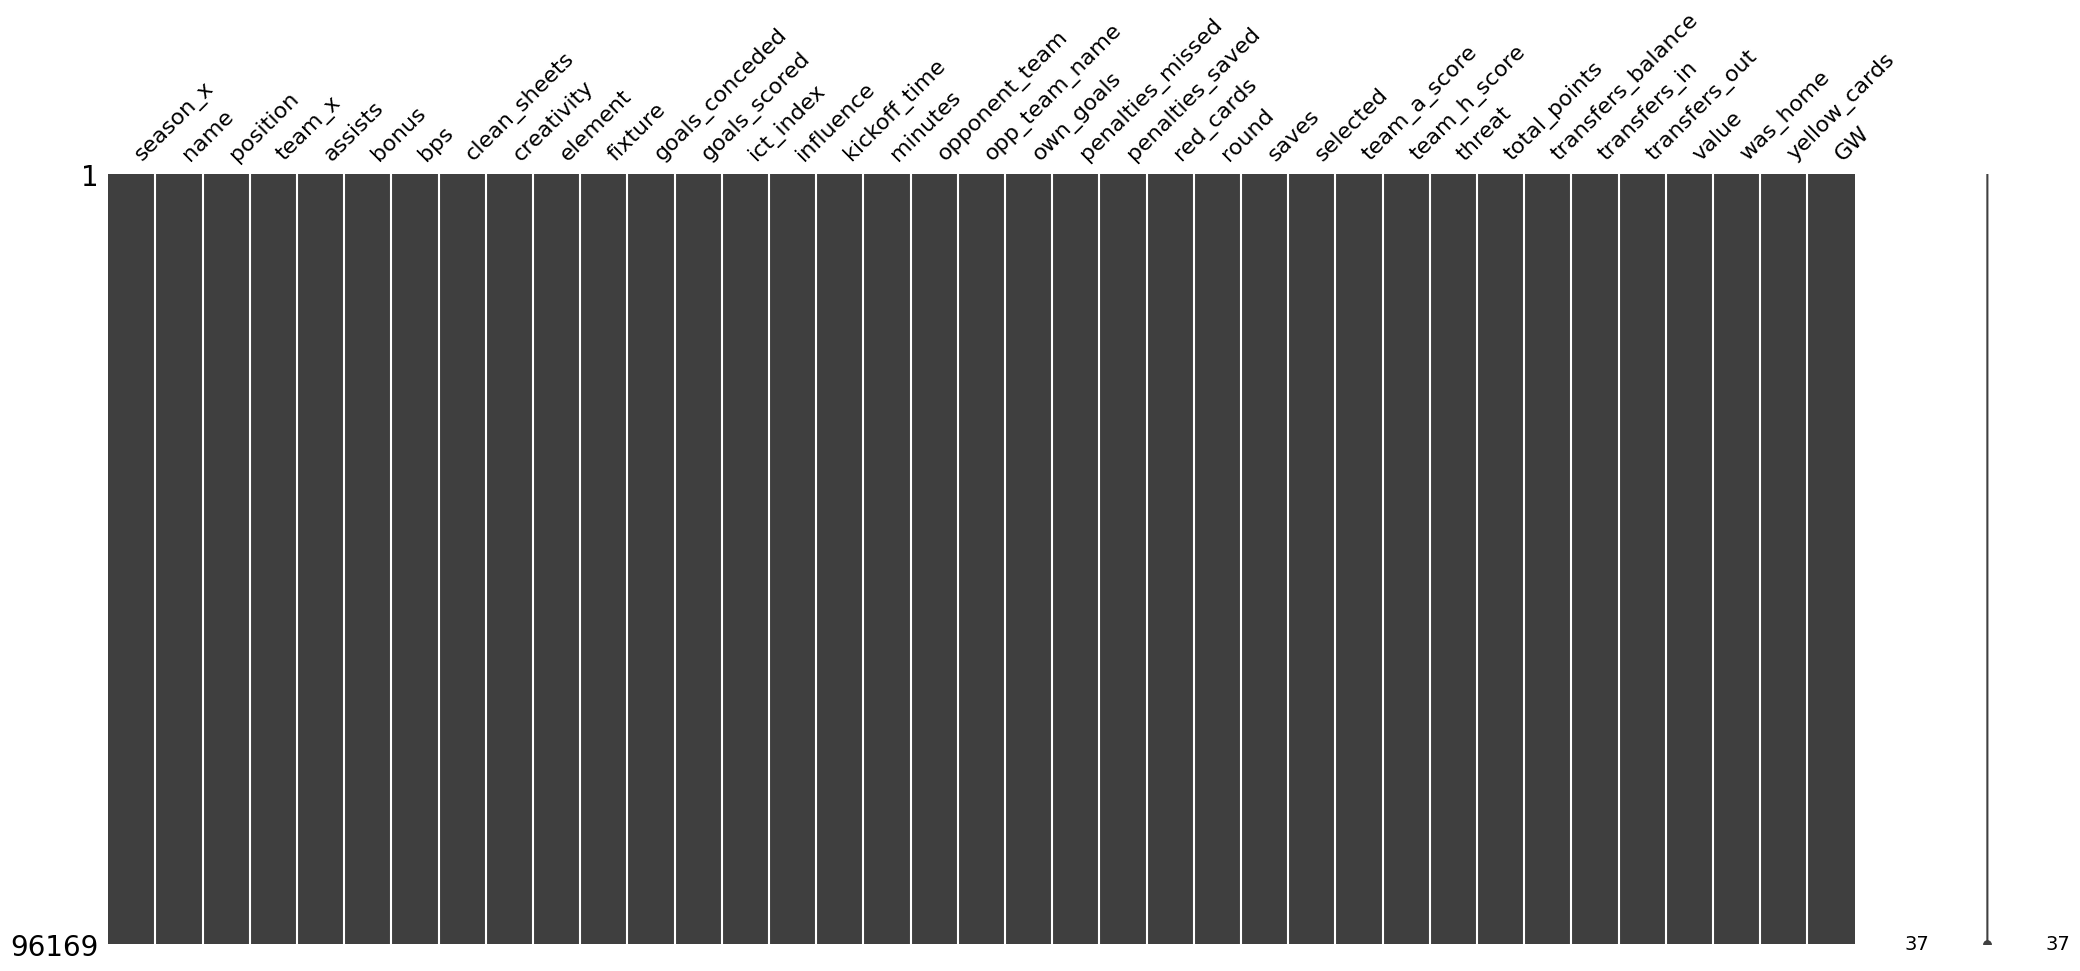

In [26]:
msno.matrix(fpl_copy)

## Checking for Duplicates

In [27]:
duplicates = fpl[fpl_copy.duplicated()]

In [28]:
duplicates.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW


In [29]:
duplicates.count()

season_x             0
name                 0
position             0
team_x               0
assists              0
bonus                0
bps                  0
clean_sheets         0
creativity           0
element              0
fixture              0
goals_conceded       0
goals_scored         0
ict_index            0
influence            0
kickoff_time         0
minutes              0
opponent_team        0
opp_team_name        0
own_goals            0
penalties_missed     0
penalties_saved      0
red_cards            0
round                0
saves                0
selected             0
team_a_score         0
team_h_score         0
threat               0
total_points         0
transfers_balance    0
transfers_in         0
transfers_out        0
value                0
was_home             0
yellow_cards         0
GW                   0
dtype: int64

## Checking for Data Inconsistencies

We noticed that goalkeeper position is written in two different formats "GK" and "GKP" so we are standarizing the way it is addressed

In [30]:
fpl_copy.position.unique()

array(['DEF', 'MID', 'GK', 'FWD', 'GKP'], dtype=object)

In [31]:
fpl_copy["position"] = fpl_copy["position"].replace({"GKP": "GK"})

In [32]:
position_encoded = pd.get_dummies(fpl_copy['position'], prefix='pos', dtype = int)
fpl_copy = pd.concat([fpl_copy, position_encoded], axis=1)
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,False,0,1,1,0,0,0
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,True,0,1,0,0,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,True,0,1,0,0,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,False,0,1,0,0,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,True,1,1,0,0,0,1


In [33]:
fpl_copy["position"].unique()

array(['DEF', 'MID', 'GK', 'FWD'], dtype=object)

# Data Transformation

### Checking for Data Consistency

Here we are converting from true, false to integer so that we can include it in the model

In [34]:
fpl_copy["was_home"] = fpl_copy["was_home"].astype(int)

In [35]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1


##########################################

In [36]:
sorted_teams = sorted(fpl_copy["team_x"].unique())
sorted_teams

['Arsenal',
 'Aston Villa',
 'Bournemouth',
 'Brentford',
 'Brighton',
 'Burnley',
 'Chelsea',
 'Crystal Palace',
 'Everton',
 'Fulham',
 'Huddersfield',
 'Hull',
 'Leeds',
 'Leicester',
 'Liverpool',
 'Man City',
 'Man Utd',
 'Middlesbrough',
 'Newcastle',
 'Norwich',
 "Nott'm Forest",
 'Sheffield Utd',
 'Southampton',
 'Spurs',
 'Stoke',
 'Sunderland',
 'Swansea',
 'Watford',
 'West Brom',
 'West Ham',
 'Wolves']

In [37]:
team_x_unique = set(fpl_copy['team_x'].unique())
opp_team_name_unique = set(fpl_copy['opp_team_name'].unique())

difference_team_x = team_x_unique - opp_team_name_unique
difference_opp_team_name = opp_team_name_unique - team_x_unique

print("Values in team_x not in opp_team_name:", difference_team_x)
print("Values in opp_team_name not in team_x:", difference_opp_team_name)

Values in team_x not in opp_team_name: set()
Values in opp_team_name not in team_x: set()


#### Checking for consistency in the name column

Insights: 

last name may differ from the same player like Adama Traoré',
 'Adama Traoré Diarra', 

 and first name 

 'Aboubakar Kamara',
 'Abu Kamara',

If we can't a common column, then our best bet is a fuzzy approach however luckily we found on the github some extra data sets that have a column called code that is consistent across seasons

Proposed Fuzzy Technique: 

- Across different Seasons, check if two or more players >15 common characters (or shorter name is present in longer version of same name) (Or a better technique)
- Check if those players play for the same team
- Check if the player has the same position

we notice here that the element(id) of a player is the same throughout the same season but differs in different seasons

We need to find a way to connect same players throughout different seasons

This is the data set that we are going to match id with element and then add the code which is the thing consistent throughout seasons, this data is acquired from the github repo of the kaggle dataset provider found at: https://github.com/vaastav/Fantasy-Premier-League/blob/master/data/

In [38]:
raw_16_17 = pd.read_csv('./supplementary_data_sets/players_raw_16_17.csv')
raw_17_18 = pd.read_csv('./supplementary_data_sets/players_raw_17_18.csv')
raw_20_21 = pd.read_csv('./supplementary_data_sets/players_raw_20_21.csv')
raw_21_22 = pd.read_csv('./supplementary_data_sets/players_raw_21_22.csv')
raw_22_23 = pd.read_csv('./supplementary_data_sets/players_raw_22_23.csv')


In [39]:
raw_16_17.head()

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,creativity,dreamteam_count,ea_index,element_type,ep_next,ep_this,event_points,first_name,form,goals_conceded,goals_scored,ict_index,id,in_dreamteam,influence,loaned_in,loaned_out,loans_in,loans_out,minutes,news,now_cost,own_goals,penalties_missed,penalties_saved,photo,points_per_game,red_cards,saves,second_name,selected_by_percent,special,squad_number,status,team,team_code,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
0,0,0,18,100.0,100.0,0,48844,0,0,-3,3,0.0,0,56,1,0.0,0.0,0,David,0.0,4,0,2.9,1,False,28.8,0,0,0,0,143,NaN,47,0,0,0,48844.jpg,1.0,0,4,Ospina,0.2,False,13.0,a,1,3,0.0,2,3433,0,7905,0,0.0,0.4,Ospina,0
1,0,2,660,100.0,100.0,12,11334,0,0,-1,1,0.1,0,409,1,6.0,0.0,4,Petr,0.0,37,0,82.0,2,False,819.8,0,0,0,0,3097,NaN,54,1,0,0,11334.jpg,3.8,0,115,Cech,13.7,False,33.0,a,1,3,0.0,134,432837,0,590727,0,0.0,24.8,Cech,2
2,1,19,723,0.0,75.0,10,51507,0,0,1,-1,53.9,3,493,2,1.7,0.0,-2,Laurent,0.0,37,2,112.7,3,False,831.2,0,0,0,0,2821,Suspended - unknown return date,61,0,0,0,51507.jpg,3.7,1,0,Koscielny,11.2,False,6.0,s,1,3,239.0,121,965040,0,857277,0,0.0,19.8,Koscielny,4
3,0,0,5,100.0,100.0,0,17127,0,0,-2,2,0.1,0,265,2,0.0,0.0,1,Per,0.0,1,0,1.8,4,False,17.8,0,0,0,0,38,NaN,48,0,0,0,17127.jpg,1.0,0,0,Mertesacker,0.2,False,4.0,a,1,3,0.0,1,2141,0,5912,0,0.0,0.2,Mertesacker,0
4,0,2,296,75.0,100.0,5,158074,0,0,-2,2,84.5,0,244,2,1.0,0.0,0,Gabriel Armando,0.0,18,0,50.0,5,False,295.8,0,0,0,0,1517,Knee injury - 75% chance of playing,48,0,0,0,158074.jpg,2.4,0,0,de Abreu,0.8,False,5.0,d,1,3,119.0,45,119600,0,100361,0,0.0,9.4,Gabriel,6


In [40]:
sorted_players = sorted(fpl_copy["name"].unique())
sorted_players

['Aaron Connolly',
 'Aaron Cresswell',
 'Aaron Hickey',
 'Aaron Lennon',
 'Aaron Mooy',
 'Aaron Ramsdale',
 'Aaron Ramsey',
 'Aaron Wan-Bissaka',
 'Abdoulaye Doucouré',
 'Aboubakar Kamara',
 'Abu Kamara',
 'Adam Armstrong',
 'Adam Forshaw',
 'Adam Idah',
 'Adam Lallana',
 'Adam Masina',
 'Adam Smith',
 'Adam Webster',
 'Adama Traoré',
 'Adama Traoré Diarra',
 'Adedapo Awokoya-Mebude',
 'Ademipo Odubeko',
 'Ademola Lookman',
 'Adrian Blake',
 'Adrien Silva',
 'Adrián Bernabé',
 'Adrián San Miguel del Castillo',
 'Ahmed El Mohamady',
 'Ahmed El-Sayed Hegazy',
 'Ainsley Maitland-Niles',
 'Ajibola Alese',
 'Albert Sambi Lokonga',
 'Albian Ajeti',
 'Alejandro Garnacho',
 'Alejandro Garnacho Ferreyra',
 'Aleksandar Mitrović',
 'Alex Iwobi',
 'Alex Kirk',
 'Alex Kral',
 'Alex McCarthy',
 'Alex Mighten',
 'Alex Nicolao Telles',
 'Alex Oxlade-Chamberlain',
 'Alex Robertson',
 'Alex Smithies',
 'Alex Telles',
 'Alexander Isak',
 'Alexandre Jankewitz',
 'Alexandre Lacazette',
 'Alexandre Moreno L

In [41]:
fpl_copy[fpl_copy['name'].str.contains('Adama Traoré', case=False, na=False)]['team_x'].unique()

array(['Middlesbrough', 'Wolves'], dtype=object)

### Grouping by First Name

In [42]:
from collections import defaultdict

# Group by first name
first_name_groups = defaultdict(list)
for name in sorted_players:
    first = name.split()[0]
    first_name_groups[first].append(name)
# Only keep groups with more than one player
first_name_groups = {k: v for k, v in first_name_groups.items() if len(v) > 1}

first_name_groups

{'Aaron': ['Aaron Connolly',
  'Aaron Cresswell',
  'Aaron Hickey',
  'Aaron Lennon',
  'Aaron Mooy',
  'Aaron Ramsdale',
  'Aaron Ramsey',
  'Aaron Wan-Bissaka'],
 'Adam': ['Adam Armstrong',
  'Adam Forshaw',
  'Adam Idah',
  'Adam Lallana',
  'Adam Masina',
  'Adam Smith',
  'Adam Webster'],
 'Adama': ['Adama Traoré', 'Adama Traoré Diarra'],
 'Adrián': ['Adrián Bernabé', 'Adrián San Miguel del Castillo'],
 'Ahmed': ['Ahmed El Mohamady', 'Ahmed El-Sayed Hegazy'],
 'Alejandro': ['Alejandro Garnacho', 'Alejandro Garnacho Ferreyra'],
 'Alex': ['Alex Iwobi',
  'Alex Kirk',
  'Alex Kral',
  'Alex McCarthy',
  'Alex Mighten',
  'Alex Nicolao Telles',
  'Alex Oxlade-Chamberlain',
  'Alex Robertson',
  'Alex Smithies',
  'Alex Telles'],
 'Alexandre': ['Alexandre Jankewitz',
  'Alexandre Lacazette',
  'Alexandre Moreno Lopera'],
 'Alfie': ['Alfie Devine', 'Alfie Gilchrist', 'Alfie Mawson'],
 'Allan': ['Allan Marques Loureiro',
  'Allan Saint-Maximin',
  'Allan Tchaptchet'],
 'Andreas': ['Andre

### Grouping By Last Name

In [43]:
# Group by last name
last_name_groups = defaultdict(list)
for name in sorted_players:
    last = name.split()[-1]
    last_name_groups[last].append(name)
# Only keep groups with more than one player
last_name_groups = {k: v for k, v in last_name_groups.items() if len(v) > 1}
last_name_groups

{'Cresswell': ['Aaron Cresswell', 'Charlie Cresswell'],
 'Ramsey': ['Aaron Ramsey', 'Jacob Ramsey'],
 'Doucouré': ['Abdoulaye Doucouré', 'Cheick Doucouré'],
 'Kamara': ['Aboubakar Kamara',
  'Abu Kamara',
  'Boubacar Kamara',
  'Hassane Kamara'],
 'Armstrong': ['Adam Armstrong', 'Stuart Armstrong'],
 'Smith': ['Adam Smith', 'Jackson Smith', 'Jordan Smith', 'Matthew Smith'],
 'Traoré': ['Adama Traoré', 'Bertrand Traoré', 'Boubacar Traoré'],
 'Silva': ['Adrien Silva',
  'Bernardo Mota Veiga de Carvalho e Silva',
  'Bernardo Veiga de Carvalho e Silva',
  'Diego Carlos Santos Silva',
  'Diogo Teixeira da Silva',
  'Fabio Silva',
  'Gabriel Martinelli Silva',
  'Gabriel Teodoro Martinelli Silva',
  'João Victor Gomes da Silva',
  'Lucas Rodrigues Moura da Silva',
  'Thiago Emiliano da Silva',
  'Willian Borges Da Silva',
  'Willian Borges da Silva',
  'Willian José Da Silva',
  'Xande Nascimento da Costa Silva'],
 'McCarthy': ['Alex McCarthy', 'James McCarthy'],
 'Telles': ['Alex Nicolao Te

We now use the code column from the raw data set to match the players across different seasons

The steps are as follows: 
- For Each Season --> Match the element column with the id column in the corressponding raw data and add the column "code" in a new column,

In [44]:
raw_16_17['season_x'] = '2016-17'
raw_17_18['season_x'] = '2017-18'
raw_20_21['season_x'] = '2020-21'
raw_21_22['season_x'] = '2021-22'
raw_22_23['season_x'] = '2022-23'

season_mapping = {
    '2016-17': raw_16_17,  # or whatever your season identifiers are
    '2017-18': raw_17_18,
    '2020-21': raw_20_21,
    '2021-22': raw_21_22,
    '2022-23': raw_22_23
}

# Add a season identifier to each season dataframe
for season_name, df in season_mapping.items():
    df['season_x'] = season_name

# Combine all seasons
combined_seasons = pd.concat(season_mapping.values(), ignore_index=True)

# Join based on both Element and Season
fpl_copy = fpl_copy.merge(
    combined_seasons[['id', 'code', 'season_x']], 
    left_on=['element', 'season_x'], 
    right_on=['id', 'season_x'], 
    how='left'
)
fpl_copy = fpl_copy.drop('id', axis=1)

fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code
60957,2021-22,Christian Kabasele,DEF,Watford,0,0,7,0,4.8,384,190,1,0,1.3,3.6,2022-03-10T19:30:00Z,60,20,Wolves,0,0,0,0,28,0,4127,0.0,4.0,5.0,2,-8,32,40,43,0,0,28,1,0,0,0,85624
88801,2022-23,Ethan Ampadu,DEF,Chelsea,0,0,0,0,0.0,151,74,0,0,0.0,0.0,2023-04-04T19:00:00Z,0,12,Liverpool,0,0,0,0,29,0,4079,0.0,0.0,0.0,0,-14,0,14,44,1,0,29,1,0,0,0,199598
13827,2017-18,Aaron Mooy,MID,Huddersfield,0,0,3,0,19.3,172,258,2,0,6.3,10.8,2018-02-03T15:00:00Z,57,12,Man Utd,0,0,0,0,26,0,341863,0.0,2.0,33.0,1,-14277,4057,18334,54,0,0,26,0,0,0,1,74471
90528,2022-23,Nathaniel Chalobah,MID,Fulham,0,0,0,0,0.0,203,316,0,0,0.0,0.0,2023-04-22T11:30:00Z,0,11,Leeds,0,0,0,0,32,0,7758,1.0,2.0,0.0,0,-43,0,43,44,1,0,32,0,0,0,1,89085
40246,2020-21,Scott Dann,DEF,Crystal Palace,0,0,9,0,0.3,486,323,2,0,1.3,11.0,2021-04-26T19:00:00Z,90,9,Leicester,0,0,0,0,33,0,37048,1.0,2.0,2.0,1,-239,47,286,42,0,0,33,1,0,0,0,19188
84462,2022-23,Nayef Aguerd,DEF,West Ham,0,0,12,0,0.8,472,239,2,0,2.1,18.0,2023-02-19T16:30:00Z,90,18,Spurs,0,0,0,0,24,0,15973,0.0,2.0,2.0,1,-2645,414,3059,48,0,0,24,1,0,0,0,210494
43541,2020-21,Emerson Palmieri dos Santos,DEF,Chelsea,0,0,0,0,0.0,111,370,0,0,0.0,0.0,2021-05-23T15:00:00Z,0,2,Aston Villa,0,0,0,0,38,0,11482,1.0,2.0,0.0,0,-7,59,66,47,0,0,38,1,0,0,0,109533
49112,2021-22,Diego Llorente,DEF,Leeds,0,0,17,0,1.2,190,87,1,0,3.8,15.0,2021-10-23T14:00:00Z,90,20,Wolves,0,0,0,0,9,0,37814,1.0,1.0,22.0,2,6918,10832,3914,45,1,0,9,1,0,0,0,149915
39213,2020-21,Karlo Ziger,GK,Chelsea,0,0,0,0,0.0,593,301,0,0,0.0,0.0,2021-04-10T16:30:00Z,0,6,Crystal Palace,0,0,0,0,31,0,52242,4.0,1.0,0.0,0,-604,152,756,40,0,0,31,0,0,1,0,431019
52131,2021-22,Andriy Yarmolenko,MID,West Ham,0,0,0,0,0.0,412,136,0,0,0.0,0.0,2021-12-01T19:30:00Z,0,4,Brighton,0,0,0,0,14,0,9993,1.0,1.0,0.0,0,-52,179,231,51,1,0,14,0,0,0,1,56377


In [45]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0,55459
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1,17349
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1,121599
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1,80179


# Feature Engineering

## Creating global codes for teams

- Since the opponent_team_code column changes for the teams from one season to another, we set a global code for each team and assiging it as a global value accross all seasons

In [46]:
unique_team_codes = pd.DataFrame(master["team_name"].unique(), columns=["team_name"])
unique_team_codes = unique_team_codes.reset_index().rename(columns={'index': 'team_global_code'})

- setting the code for the playes's team according to the team_x column

In [47]:
fpl_copy = fpl_copy.merge(
    unique_team_codes,
    how='left',
    left_on='team_x',
    right_on='team_name'
).rename(columns={'team_global_code': 'team_x_global_code'})
fpl_copy = fpl_copy.drop(columns=['team_name'])

- setting the code for opponent team according to opp_team_name column

In [48]:
fpl_copy = fpl_copy.merge(
    unique_team_codes,
    how='left',
    left_on='opp_team_name',
    right_on='team_name'
).rename(columns={'team_global_code': 'opponent_team_global_code'})
fpl_copy = fpl_copy.drop(columns=['team_name'])

In [49]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,0,0,1,1,0,0,0,55459,19,3
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,1,0,1,0,0,0,1,17349,5,16
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792,0,8
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,0,0,1,0,0,0,1,121599,17,12
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,1,1,1,0,0,0,1,80179,11,13


## Create upcoming total points column

- We need to create the label, which is the upcoming_total_points for each player
- We then need to make sure that the last match for any player to be set to NA
- We chose the approach to nullify the last match only so 1 game for each player, so upcoming total points carries from one season to another

In [50]:
# Sort properly first
fpl_copy = fpl_copy.sort_values(['code', 'season_x', 'GW'])

# Upcoming total points (next GW)
fpl_copy['upcoming_total_points'] = fpl_copy.groupby(['code'])['total_points'].shift(-1)

#set the last instance 
last_indices = fpl_copy.groupby('code').tail(1).index
fpl_copy.loc[last_indices, 'upcoming_total_points'] = pd.NA


In [51]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points
7409,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,37,0,0,0.0,0.0,2016-09-10T14:00:00Z,0,17,Spurs,0,0,0,0,4,0,376,4.0,0.0,0.0,0,211,230,19,40,1,0,4,0,0,1,0,6744,13,16,0.0
7622,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,47,0,0,0.0,0.0,2016-09-18T13:15:00Z,0,5,Crystal Palace,0,0,0,0,5,0,1807,1.0,4.0,0.0,0,607,712,105,40,0,0,5,0,0,1,0,6744,13,4,2.0
7835,2016-17,Lee Grant,GK,Stoke,0,0,13,0,0.0,574,56,1,0,1.4,14.0,2016-09-24T14:00:00Z,90,19,West Brom,0,0,0,0,6,2,3232,1.0,1.0,0.0,2,668,878,210,40,1,0,6,0,0,1,0,6744,13,18,5.0
8048,2016-17,Lee Grant,GK,Stoke,0,1,24,0,0.0,574,65,1,0,5.9,59.0,2016-10-02T11:00:00Z,90,11,Man Utd,0,0,0,0,7,8,8564,1.0,1.0,0.0,5,4034,4546,512,40,0,0,7,0,0,1,0,6744,13,10,6.0
8262,2016-17,Lee Grant,GK,Stoke,0,0,23,1,0.0,574,79,0,0,0.8,8.2,2016-10-15T14:00:00Z,90,15,Sunderland,0,0,0,0,8,1,32985,0.0,2.0,0.0,6,20881,21951,1070,40,1,0,8,0,0,1,0,6744,13,14,6.0


Here we check again for duplicates for same gameweek, DGW19 for Salah in 2020/21 for example
- We dont think we should combine both records because points might be an outlier --> he did really well in both gameweeks
- we shouldn't delete the records since they are important <br>
$\textbf{Hypothesis Driven Step}:$ <br>
Therefore, here we opt to do nothing to double gameweeks record because we hypothesize that any sort of combining might introduce some outliers, and we hypothesize that it is logical for the upcoming total points for the next gameweek to change from match to match within the same gameweek if multiple are played.

In [52]:
salah_matches = fpl_copy[(fpl_copy['name'] == 'Mohamed Salah')]
duplicates = salah_matches[salah_matches.duplicated(subset=['season_x', 'GW'], keep=False)]
duplicates

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points
30174,2020-21,Mohamed Salah,MID,Liverpool,0,0,6,1,28.4,254,184,0,0,8.1,7.2,2021-01-17T16:30:00Z,90,13,Man Utd,0,0,0,0,19,0,3168283,0.0,0.0,45.0,3,89606,195898,106292,125,1,0,19,0,0,0,1,118748,8,10,1.0
30175,2020-21,Mohamed Salah,MID,Liverpool,0,0,2,0,14.6,254,177,1,0,6.7,5.8,2021-01-21T20:00:00Z,33,4,Burnley,0,0,0,0,19,0,3168283,1.0,0.0,47.0,1,89606,195898,106292,125,1,0,19,0,0,0,1,118748,8,2,2.0
35347,2020-21,Mohamed Salah,MID,Liverpool,0,0,10,1,19.6,254,256,0,0,7.6,8.6,2021-02-28T19:15:00Z,90,15,Sheffield Utd,0,0,0,0,26,0,3327142,2.0,0.0,48.0,3,-144540,71659,216199,126,0,0,26,0,0,0,1,118748,8,28,2.0
35348,2020-21,Mohamed Salah,MID,Liverpool,0,0,10,0,15.4,254,283,1,0,3.6,10.6,2021-03-04T20:15:00Z,61,5,Chelsea,0,0,0,0,26,0,3327142,1.0,0.0,10.0,2,-144540,71659,216199,126,1,0,26,0,0,0,1,118748,8,3,2.0
41358,2020-21,Mohamed Salah,MID,Liverpool,1,0,16,1,31.7,254,344,0,0,16.0,32.4,2021-05-08T19:15:00Z,86,16,Southampton,0,0,0,0,35,0,2982553,0.0,2.0,96.0,6,83689,143359,59670,127,1,0,35,0,0,0,1,118748,8,12,7.0
41359,2020-21,Mohamed Salah,MID,Liverpool,0,0,22,0,23.5,254,334,2,1,11.2,33.2,2021-05-13T19:15:00Z,90,13,Man Utd,0,0,0,0,35,0,2982553,4.0,2.0,55.0,7,83689,143359,59670,127,0,0,35,0,0,0,1,118748,8,10,10.0
59342,2021-22,Mohamed Salah,MID,Liverpool,0,3,34,0,69.3,233,256,1,1,22.7,48.2,2022-02-19T15:00:00Z,90,15,Norwich,0,0,0,0,26,0,5419768,1.0,3.0,109.0,10,1256075,1263924,7849,131,1,0,26,0,0,0,1,118748,8,27,18.0
59343,2021-22,Mohamed Salah,MID,Liverpool,1,2,54,1,22.0,233,184,0,2,19.9,87.6,2022-02-23T19:45:00Z,90,10,Leeds,0,0,0,0,26,0,5419768,0.0,6.0,89.0,18,1256075,1263924,7849,131,1,0,26,0,0,0,1,118748,8,29,3.0
61968,2021-22,Mohamed Salah,MID,Liverpool,0,1,26,1,12.4,233,283,0,1,15.3,38.8,2022-03-12T12:30:00Z,64,4,Brighton,0,0,0,0,29,0,5722763,2.0,0.0,102.0,9,201217,224096,22879,133,0,0,29,0,0,0,1,118748,8,20,1.0
61969,2021-22,Mohamed Salah,MID,Liverpool,0,0,-2,0,2.7,233,261,0,0,4.3,0.0,2022-03-16T20:15:00Z,34,1,Arsenal,0,0,0,0,29,0,5722763,2.0,0.0,41.0,1,201217,224096,22879,133,0,0,29,0,0,0,1,118748,8,0,3.0


- Here we check for the total numbe rof null values against the count of unique players to make sure that the last game for each player is set to NA

In [53]:
num_nulls = fpl_copy['upcoming_total_points'].isnull().sum()
num_unique_players = fpl_copy['code'].nunique()

print(num_nulls, num_unique_players)

1264 1264


## Creating Form Column 

- We create the form column by calculating the mean of the last 4 game weeks (if available)
- We allow the form to carry from one season to another

In [54]:

fpl_copy['form'] = (
    fpl_copy.groupby('code')['total_points']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()) / 10
)
fpl_copy['form'].fillna(0, inplace=True)
fpl_copy.head()

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\12840432.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fpl_copy['form'].fillna(0, inplace=True)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form
7409,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,37,0,0,0.0,0.0,2016-09-10T14:00:00Z,0,17,Spurs,0,0,0,0,4,0,376,4.0,0.0,0.0,0,211,230,19,40,1,0,4,0,0,1,0,6744,13,16,0.0,0.000000
7622,2016-17,Lee Grant,GK,Stoke,0,0,0,0,0.0,574,47,0,0,0.0,0.0,2016-09-18T13:15:00Z,0,5,Crystal Palace,0,0,0,0,5,0,1807,1.0,4.0,0.0,0,607,712,105,40,0,0,5,0,0,1,0,6744,13,4,2.0,0.000000
7835,2016-17,Lee Grant,GK,Stoke,0,0,13,0,0.0,574,56,1,0,1.4,14.0,2016-09-24T14:00:00Z,90,19,West Brom,0,0,0,0,6,2,3232,1.0,1.0,0.0,2,668,878,210,40,1,0,6,0,0,1,0,6744,13,18,5.0,0.000000
8048,2016-17,Lee Grant,GK,Stoke,0,1,24,0,0.0,574,65,1,0,5.9,59.0,2016-10-02T11:00:00Z,90,11,Man Utd,0,0,0,0,7,8,8564,1.0,1.0,0.0,5,4034,4546,512,40,0,0,7,0,0,1,0,6744,13,10,6.0,0.066667
8262,2016-17,Lee Grant,GK,Stoke,0,0,23,1,0.0,574,79,0,0,0.8,8.2,2016-10-15T14:00:00Z,90,15,Sunderland,0,0,0,0,8,1,32985,0.0,2.0,0.0,6,20881,21951,1070,40,1,0,8,0,0,1,0,6744,13,14,6.0,0.175000


In [55]:
# Explicit mapping for the five seasons
season_code_map = {
    '2016-17': 1,
    '2017-18': 2,
    '2020-21': 3,
    '2021-22': 4,
    '2022-23': 5
}

# Create the code column (unknown/missing -> 0)
fpl_copy['season_x_code'] = fpl_copy['season_x'].map(season_code_map).fillna(0).astype(int)
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code
90,2016-17,Jarrod Bowen,MID,Hull,0,0,0,0,0.0,516,4,0,0,0.0,0.0,2016-08-13T11:30:00Z,0,8,Leicester,0,0,0,0,1,0,0,1.0,2.0,0.0,0,0,0,0,45,1,0,1,0,0,0,1,178186,6,7,0.0,0.000,1
36710,2020-21,Takumi Minamino,MID,Southampton,0,0,10,1,13.0,258,265,0,0,3.3,4.6,2021-03-06T15:00:00Z,87,15,Sheffield Utd,0,0,0,0,27,0,39980,2.0,0.0,15.0,3,-2383,6808,9191,60,0,0,27,0,0,0,1,157882,12,28,0.0,0.300,3
75249,2022-23,Mads Bech Sørensen,DEF,Brentford,0,0,0,0,0.0,91,102,0,0,0.0,0.0,2022-10-14T19:00:00Z,0,5,Brighton,0,0,0,0,11,0,4157,0.0,2.0,0.0,0,-146,0,146,45,1,0,11,1,0,0,0,228044,30,20,0.0,0.000,5
39141,2020-21,Charlie Austin,FWD,West Brom,0,0,0,0,0.0,415,307,0,0,0.0,0.0,2021-04-12T17:00:00Z,0,16,Southampton,0,0,0,0,31,0,11630,0.0,3.0,0.0,0,-34,0,34,51,1,0,31,0,1,0,0,78356,18,12,0.0,0.000,3
47020,2021-22,Ian Carlo Poveda-Ocampo,MID,Leeds,0,0,0,0,0.0,195,46,0,0,0.0,0.0,2021-09-17T19:00:00Z,0,14,Newcastle,0,0,0,0,5,0,3098,1.0,1.0,0.0,0,-552,0,552,45,0,0,5,0,0,0,1,215460,29,22,0.0,0.000,4
76514,2022-23,Michael Olise,MID,Crystal Palace,0,0,9,0,2.2,171,123,1,0,4.2,2.6,2022-10-22T14:00:00Z,61,8,Everton,0,0,0,0,13,0,21592,0.0,3.0,37.0,2,2298,3596,1298,54,0,0,13,0,0,0,1,443661,4,5,3.0,0.325,5
64096,2021-22,Roberto Firmino,FWD,Liverpool,0,0,3,0,0.0,228,316,0,0,0.0,0.0,2022-04-10T15:30:00Z,6,12,Man City,0,0,0,0,32,0,222764,2.0,2.0,0.0,1,-2203,3015,5218,87,0,0,32,0,1,0,0,92217,8,9,0.0,0.150,4
83546,2022-23,Mateusz Lis,GK,Southampton,0,0,0,0,0.0,421,229,0,0,0.0,0.0,2023-02-11T15:00:00Z,0,20,Wolves,0,0,0,0,23,0,15627,2.0,1.0,0.0,0,-148,0,148,40,1,0,23,0,0,1,0,200428,12,25,0.0,0.000,5
57089,2021-22,Theo Walcott,MID,Southampton,0,0,0,0,0.0,332,229,0,0,0.0,0.0,2022-01-22T17:30:00Z,0,12,Man City,0,0,0,0,23,0,9732,1.0,1.0,0.0,0,-160,40,200,58,1,0,23,0,0,0,1,20467,12,9,1.0,0.050,4
67782,2021-22,Calum Chambers,DEF,Aston Villa,0,0,0,0,0.0,10,321,0,0,0.0,0.0,2022-05-10T19:00:00Z,0,11,Liverpool,0,0,0,0,36,0,34161,2.0,1.0,0.0,0,4723,5691,968,42,1,0,36,1,0,0,0,101184,26,8,1.0,0.275,4


## Calculating Team Strength Column

In [56]:
fpl_copy = fpl_copy.sort_values(['season_x', 'GW', 'team_x_global_code'])


team_week_avg = (
    fpl_copy.groupby(['season_x', 'GW', 'team_x_global_code'])['total_points']
    .mean()
    .reset_index()
    .rename(columns={'total_points': 'team_avg_points'})
)

In [57]:
team_week_avg['team_strength'] = (
    team_week_avg.groupby(['season_x', 'team_x_global_code'])['team_avg_points']
    .transform(lambda x: x.shift(1).expanding().mean())
)

fpl_copy = fpl_copy.merge(
    team_week_avg[['season_x', 'GW', 'team_x_global_code', 'team_strength']],
    on=['season_x', 'GW', 'team_x_global_code'],
    how='left'
)

In [58]:
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength
63713,2021-22,Christian Eriksen,MID,Brentford,0,2,40,0,44.5,699,303,1,1,11.6,53.6,2022-04-02T14:00:00Z,90,6,Chelsea,0,0,0,0,31,0,36970,4.0,1.0,18.0,9,-3895,4626,8521,55,0,0,31,0,0,0,1,80607,30,3,3.0,0.200,4,1.111005
13922,2017-18,Nathaniel Chalobah,MID,Watford,0,0,0,0,0.0,112,182,0,0,0.0,0.0,2017-12-23T15:00:00Z,0,3,Brighton,0,0,0,0,19,0,46250,0.0,1.0,0.0,0,-2446,128,2574,43,0,0,19,0,0,0,1,89085,17,20,0.0,0.000,2,2.338889
85423,2022-23,Hwang Hee-chan,MID,Wolves,0,0,0,0,0.0,481,244,0,0,0.0,0.0,2023-02-24T20:00:00Z,0,9,Fulham,0,0,0,0,25,0,16003,1.0,1.0,0.0,0,-204,85,289,57,0,0,25,0,0,0,1,184754,25,24,0.0,0.125,5,1.147999
93113,2022-23,Konstantinos Tsimikas,DEF,Liverpool,0,0,3,0,0.4,292,344,0,0,0.1,0.4,2023-05-06T16:30:00Z,8,4,Brentford,0,0,0,0,35,0,25626,0.0,1.0,0.0,1,127,488,361,43,1,0,35,1,0,0,0,214285,8,30,0.0,0.150,5,1.372733
1492,2016-17,Michy Batshuayi,FWD,Chelsea,0,0,0,0,0.0,96,73,0,0,0.0,0.0,2016-10-15T11:30:00Z,0,8,Leicester,0,0,0,0,8,0,47903,0.0,3.0,0.0,0,-4084,325,4409,87,1,0,8,0,1,0,0,94245,3,7,1.0,0.050,1,2.118263
56733,2021-22,Paul Dummett,DEF,Newcastle,0,0,9,0,1.4,301,216,1,0,1.3,11.8,2022-01-15T15:00:00Z,90,18,Watford,0,0,0,0,22,0,952,1.0,1.0,0.0,1,30,85,55,45,1,1,22,1,0,0,0,106618,22,17,5.0,0.000,4,1.054485
33520,2020-21,Bernd Leno,GK,Arsenal,0,0,16,0,0.0,8,229,2,0,2.3,23.0,2021-02-14T16:30:00Z,90,10,Leeds,0,0,0,0,24,3,565889,2.0,4.0,0.0,2,-26979,6244,33223,50,1,0,24,0,0,1,0,80201,0,29,2.0,0.225,3,1.284788
38720,2020-21,Joel Ward,DEF,Crystal Palace,0,0,5,0,1.4,134,301,4,0,0.7,5.2,2021-04-10T16:30:00Z,90,5,Chelsea,0,0,0,0,31,0,59024,4.0,1.0,0.0,0,2481,4011,1530,43,1,0,31,1,0,0,0,55494,4,3,1.0,0.450,3,1.195702
10828,2017-18,Ben Mee,DEF,Burnley,0,0,10,0,0.3,77,84,3,0,4.2,20.0,2017-10-21T14:00:00Z,90,11,Man City,0,0,0,0,9,0,367249,0.0,3.0,22.0,1,-6303,9239,15542,45,0,0,9,1,0,0,0,51927,2,9,9.0,0.425,2,1.944643
56504,2021-22,Theo Walcott,MID,Southampton,0,0,0,0,0.0,332,220,0,0,0.0,0.0,2022-01-15T15:00:00Z,0,20,Wolves,0,0,0,0,22,0,9870,1.0,3.0,0.0,0,-1,213,214,58,0,0,22,0,0,0,1,20467,12,25,0.0,0.075,4,1.393137


In [59]:
opp_week_avg = (
    fpl_copy.groupby(['season_x', 'GW', 'opponent_team_global_code'])['total_points']
    .mean()
    .reset_index()
    .rename(columns={
        'opponent_team_global_code': 'team_x_global_code',
        'total_points': 'team_avg_points'
    })
)

opp_week_avg['opponent_strength'] = (
    opp_week_avg.groupby(['season_x', 'team_x_global_code'])['team_avg_points']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Merge back (but this time match on opponent_team_global_code)
fpl_copy = fpl_copy.merge(
    opp_week_avg[['season_x', 'GW', 'team_x_global_code', 'opponent_strength']],
    left_on=['season_x', 'GW', 'opponent_team_global_code'],
    right_on=['season_x', 'GW', 'team_x_global_code'],
    how='left'
).drop(columns=['team_x_global_code_y']).rename(columns={'team_x_global_code_x': 'team_x_global_code'})


In [60]:
# Create strength_difference as team_strength minus opponent_strength
fpl_copy['strength_difference'] = fpl_copy['team_strength'] - fpl_copy['opponent_strength']

# Quick checks
print("Missing team_strength:", fpl_copy['team_strength'].isna().sum())
print("Missing opponent_strength:", fpl_copy['opponent_strength'].isna().sum())
print("Missing strength_difference:", fpl_copy['strength_difference'].isna().sum())

# Inspect a few rows to confirm
fpl_copy[['season_x', 'GW', 'team_x', 'opp_team_name', 'team_strength', 'opponent_strength', 'strength_difference']].sample(10)

Missing team_strength: 2127
Missing opponent_strength: 2121
Missing strength_difference: 2231


,season_x,GW,team_x,opp_team_name,team_strength,opponent_strength,strength_difference
45745,2021-22,3,Newcastle,Southampton,0.980769,1.555556,-0.574786
73401,2022-23,8,Southampton,Aston Villa,1.139683,1.707514,-0.567831
13298,2017-18,17,Swansea,Man City,2.295759,0.924966,1.370793
61267,2021-22,28,West Ham,Liverpool,1.537597,0.842178,0.695420
93366,2022-23,35,Newcastle,Arsenal,1.601330,0.878779,0.722551
70624,2022-23,2,Newcastle,Brighton,2.366667,0.586207,1.780460
80803,2022-23,19,Aston Villa,Wolves,1.159619,1.655866,-0.496246
68036,2021-22,36,Brentford,Southampton,1.142571,1.299341,-0.156770
29109,2020-21,17,Leicester,Newcastle,1.546822,1.467027,0.079795
18558,2017-18,35,Crystal Palace,Watford,1.721597,2.250932,-0.529335


In [61]:
# Fill NA in strength_difference with 0 and verify
fpl_copy['strength_difference'].fillna(0, inplace=True)
fpl_copy[['team_strength', 'opponent_strength', 'strength_difference']].isna().sum()

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\1310152204.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fpl_copy['strength_difference'].fillna(0, inplace=True)


team_strength          2127
opponent_strength      2121
strength_difference       0
dtype: int64

In [62]:
fpl_copy.sample(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
32744,2020-21,Rayan Ait Nouri,DEF,Wolves,0,0,0,0,0.0,563,215,0,0,0.0,0.0,2021-02-02T18:00:00Z,0,1,Arsenal,0,0,0,0,22,0,10047,1.0,2.0,0.0,0,-1725,32,1757,50,1,0,22,1,0,0,0,448514,25,0,0.0,0.200,3,1.210140,1.345895,-0.135754
53033,2021-22,Francisco Sierralta,DEF,Watford,0,0,0,0,0.0,396,148,0,0,0.0,0.0,2021-12-04T17:30:00Z,0,12,Man City,0,0,0,0,15,0,4309,3.0,1.0,0.0,0,-151,40,191,43,1,0,15,1,0,0,0,208973,17,9,0.0,0.000,4,0.784183,1.038210,-0.254027
38093,2020-21,Adrien Silva,MID,Leicester,0,0,0,0,0.0,220,294,0,0,0.0,0.0,2021-04-03T16:30:00Z,0,12,Man City,0,0,0,0,30,0,16620,2.0,0.0,0.0,0,-38,0,38,44,1,0,30,0,0,0,1,46483,7,9,0.0,0.000,3,1.574762,0.929227,0.645534
61803,2021-22,Omari Hutchinson,MID,Arsenal,0,0,0,0,0.0,692,281,0,0,0.0,0.0,2022-03-13T16:30:00Z,0,9,Leicester,0,0,0,0,29,0,165,0.0,2.0,0.0,0,18,39,21,45,1,0,29,0,0,0,1,503301,0,7,0.0,0.000,4,1.308156,1.285383,0.022773
25677,2020-21,Filip Benkovic,DEF,Leicester,0,0,0,0,0.0,237,105,0,0,0.0,0.0,2020-12-06T14:15:00Z,0,15,Sheffield Utd,0,0,0,0,11,0,1862,2.0,1.0,0.0,0,-45,5,50,43,0,0,11,1,0,0,0,213405,7,28,0.0,0.000,3,1.574915,2.038716,-0.463801
83029,2022-23,Bernd Leno,GK,Fulham,0,0,27,1,0.0,2,214,0,0,2.0,19.8,2023-02-03T20:00:00Z,90,6,Chelsea,0,0,0,0,22,2,258793,0.0,0.0,0.0,6,-2616,15265,17881,45,0,0,22,0,0,1,0,80201,24,3,6.0,0.475,5,1.152757,1.217158,-0.064400
34683,2020-21,Serge Aurier,DEF,Spurs,0,0,0,0,0.0,389,247,0,0,0.0,0.0,2021-02-21T12:00:00Z,0,19,West Ham,0,0,0,0,25,0,117758,1.0,2.0,0.0,0,-9549,583,10132,52,0,0,25,1,0,0,0,80226,16,19,6.0,0.200,3,1.496147,1.230054,0.266093
4348,2016-17,Patrick Bamford,FWD,Burnley,0,0,0,0,0.0,553,201,0,0,0.0,0.0,2017-01-14T15:00:00Z,0,13,Southampton,0,0,0,0,21,0,1801,0.0,1.0,0.0,0,-78,75,153,49,1,0,21,0,1,0,0,106617,2,12,1.0,0.025,1,1.793939,2.312405,-0.518466
13259,2017-18,Juan Mata,MID,Man Utd,1,0,23,1,46.7,274,164,0,0,9.1,26.6,2017-12-13T20:00:00Z,90,2,Bournemouth,0,0,0,0,17,0,104002,0.0,1.0,18.0,6,-934,1267,2201,68,1,0,17,0,0,0,1,43670,10,1,6.0,0.100,2,2.246711,1.998139,0.248571
38249,2020-21,Che Adams,FWD,Southampton,0,0,0,0,0.3,377,297,0,0,0.2,1.0,2021-04-04T11:00:00Z,4,4,Burnley,0,0,0,0,30,0,446965,2.0,3.0,1.0,1,30167,52973,22806,58,1,0,30,0,1,0,0,200439,12,2,1.0,0.550,3,1.399805,1.595355,-0.195550


## Checking Again For Corelation and Redundancy

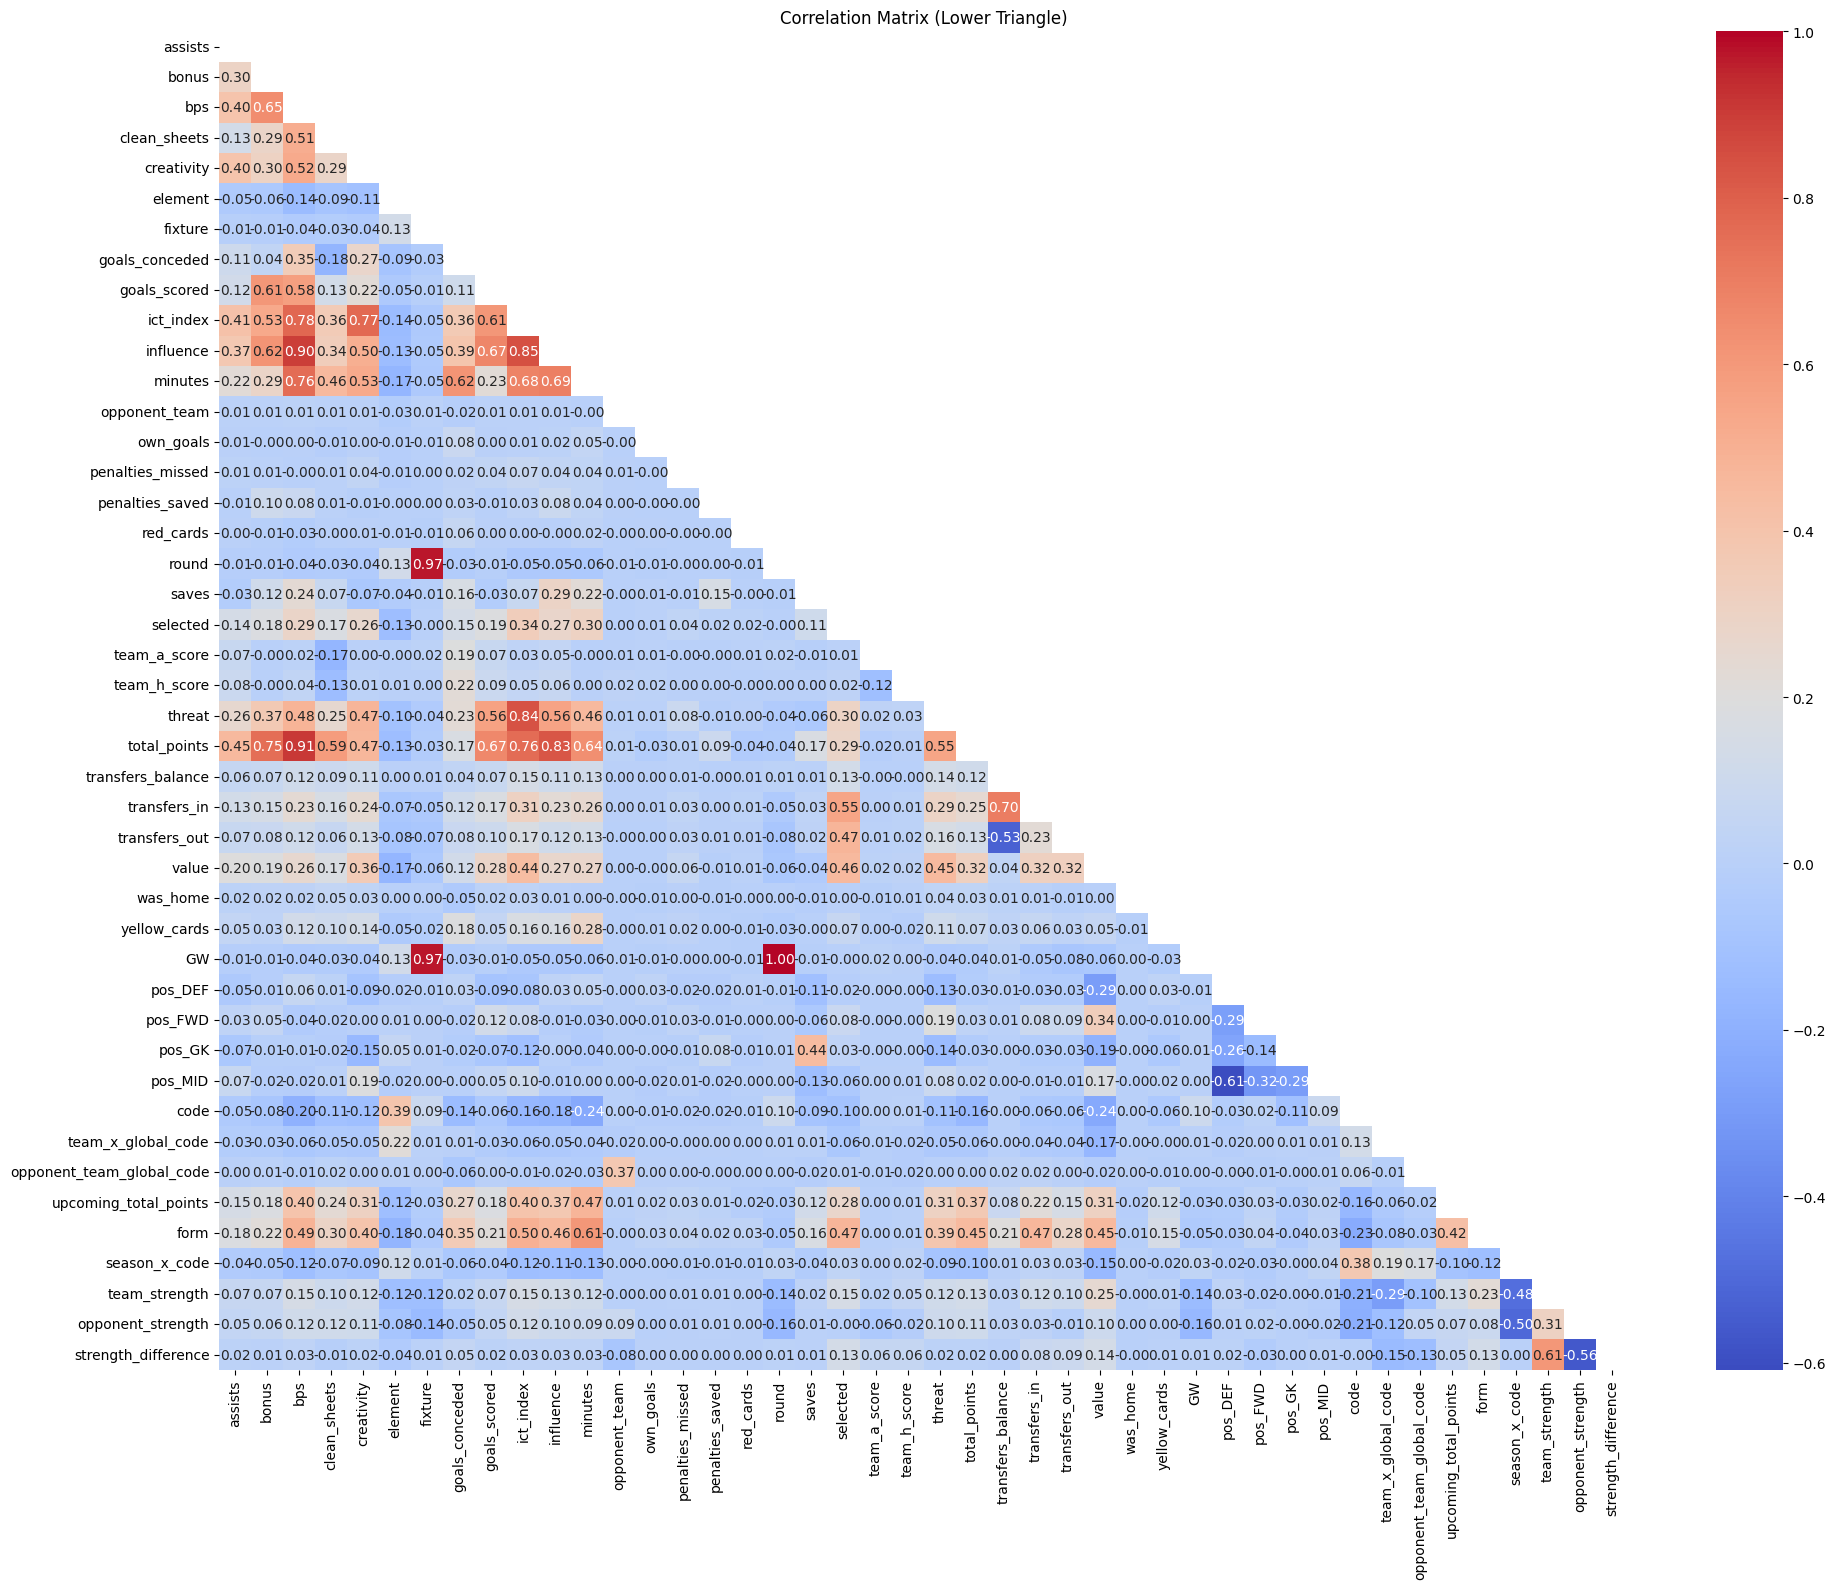

In [63]:
corr = fpl_copy.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f",
    cmap='coolwarm', 
    annot_kws={"size": 10}
)
plt.title('Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

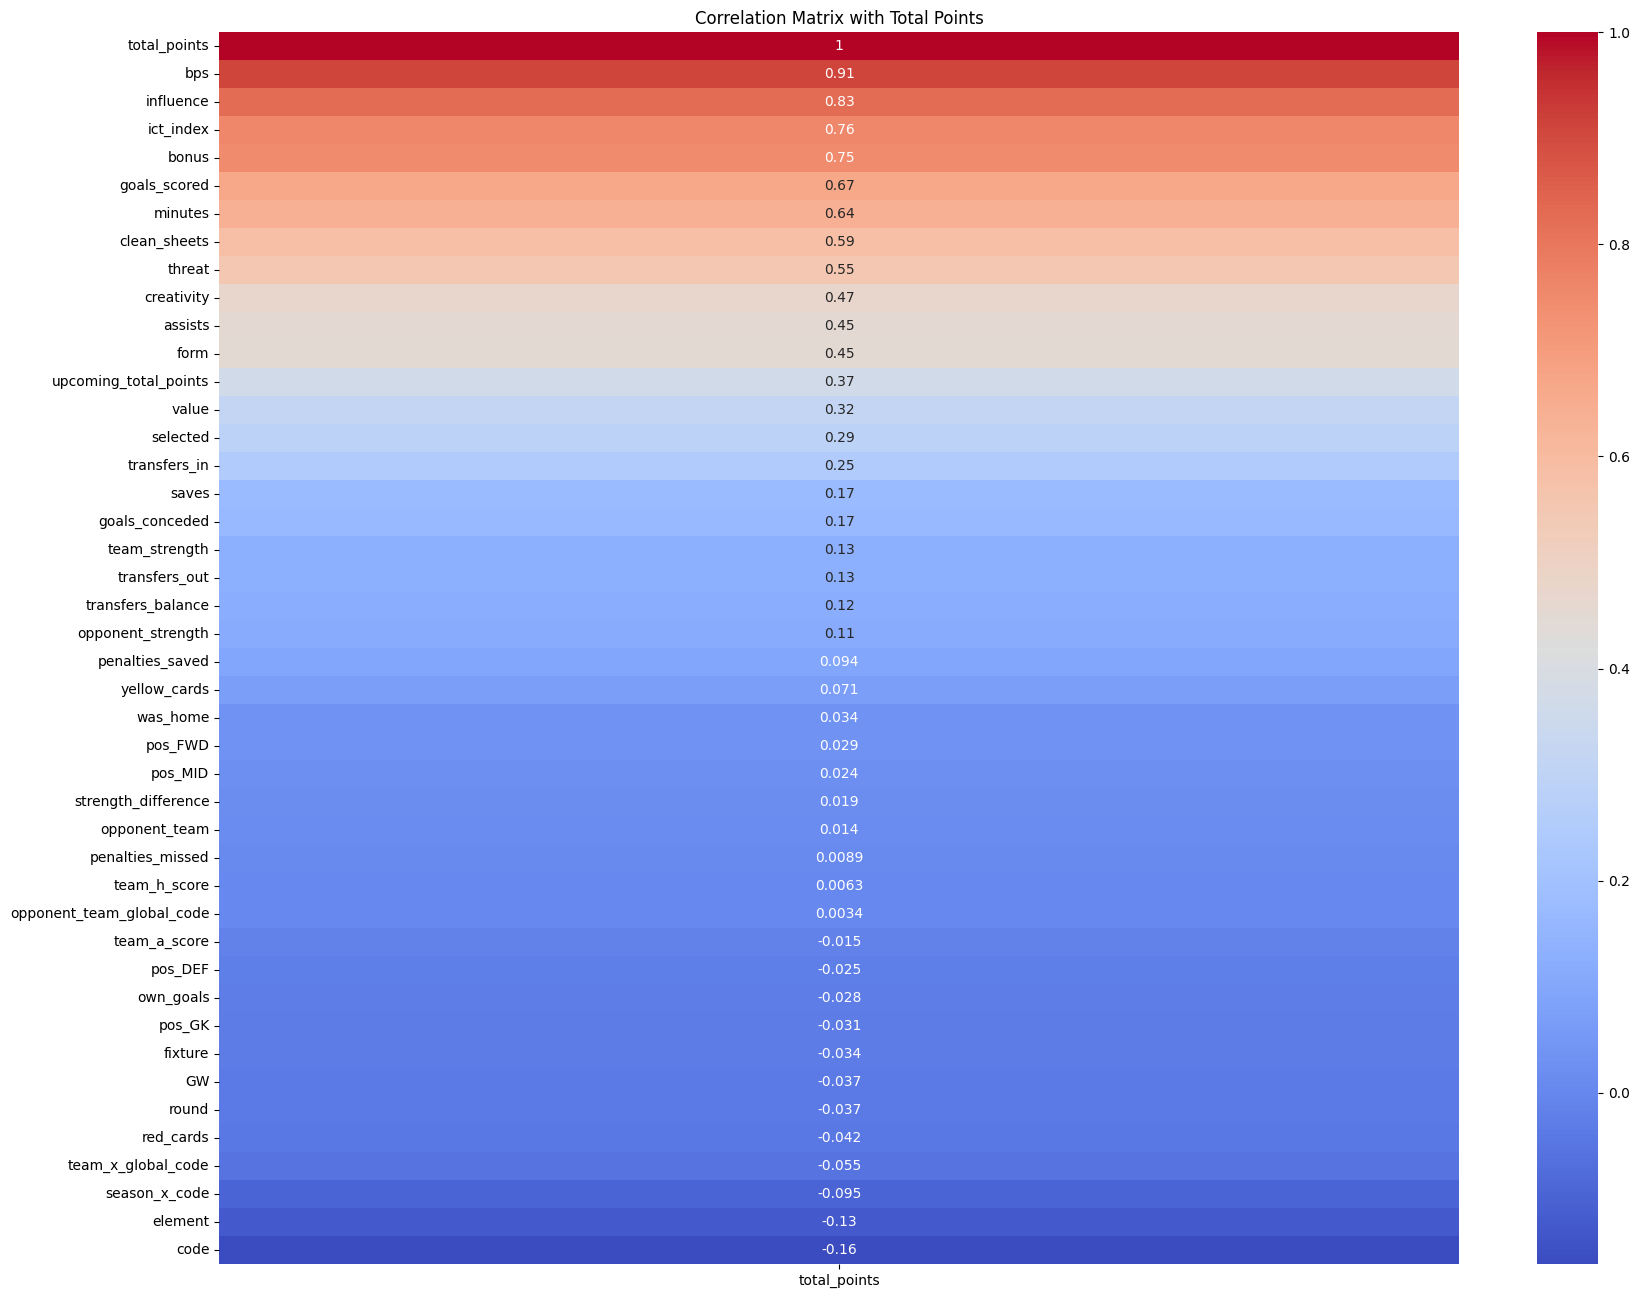

In [64]:
corr = fpl_copy.corr(numeric_only=True)
plt.figure(figsize=(20, 16))
sns.heatmap(corr[['total_points']].sort_values(by='total_points', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix with Total Points')
plt.show()

In [65]:
fpl_copy.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
0,2016-17,Theo Walcott,MID,Arsenal,0,0,21,0,20.0,13,8,4,1,10.5,46.6,2016-08-14T15:00:00Z,90,9,Liverpool,0,1,0,0,1,0,48930,4.0,3.0,38.0,5,0,0,0,75,1,0,1,0,0,0,1,20467,0,8,3.0,0.0,1,NaN,NaN,0.0
1,2016-17,Mesut Özil,MID,Arsenal,0,0,0,0,0.0,14,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,179727,4.0,3.0,0.0,0,0,0,0,95,1,0,1,0,0,0,1,37605,0,8,1.0,0.0,1,NaN,NaN,0.0
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792,0,8,0.0,0.0,1,NaN,NaN,0.0
3,2016-17,Kieran Gibbs,DEF,Arsenal,0,0,0,0,0.0,7,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,22607,4.0,3.0,0.0,0,0,0,0,50,1,0,1,1,0,0,0,42427,0,8,0.0,0.0,1,NaN,NaN,0.0
4,2016-17,Olivier Giroud,FWD,Arsenal,0,0,0,0,0.0,25,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,50997,4.0,3.0,0.0,0,0,0,0,90,1,0,1,0,1,0,0,44346,0,8,1.0,0.0,1,NaN,NaN,0.0


# Data Engineering Questions

$\text{Question A)}$ Across the seasons, which player positions (e.g., goalkeeper, defender, midfielder, etc.) score the largest sum of total points on average? <br>
Answer: for the 5 seasons we have the FWD position scoring the most points except the 2021-22 season the MID Postion is the one that scored the most points

In [66]:
ans=fpl_copy.groupby(['season_x','position'])['total_points'].mean().unstack()
for row in ans.itertuples():
    largest=-1
    pos =''
    if row.GK > largest:
        largest=row.GK
        pos='GK'
    if row.DEF > largest:
        largest=row.DEF
        pos='DEF'
    if row.MID > largest:
        largest=row.MID
        pos='MID'
    if row.FWD > largest:
        largest=row.FWD
        pos='FWD'
    print(f"{row.Index}: | Highest: {largest:.2f} | Position: {pos}")

    

2016-17: | Highest: 2.27 | Position: FWD
2017-18: | Highest: 2.11 | Position: FWD
2020-21: | Highest: 1.46 | Position: FWD
2021-22: | Highest: 1.32 | Position: MID
2022-23: | Highest: 1.42 | Position: FWD


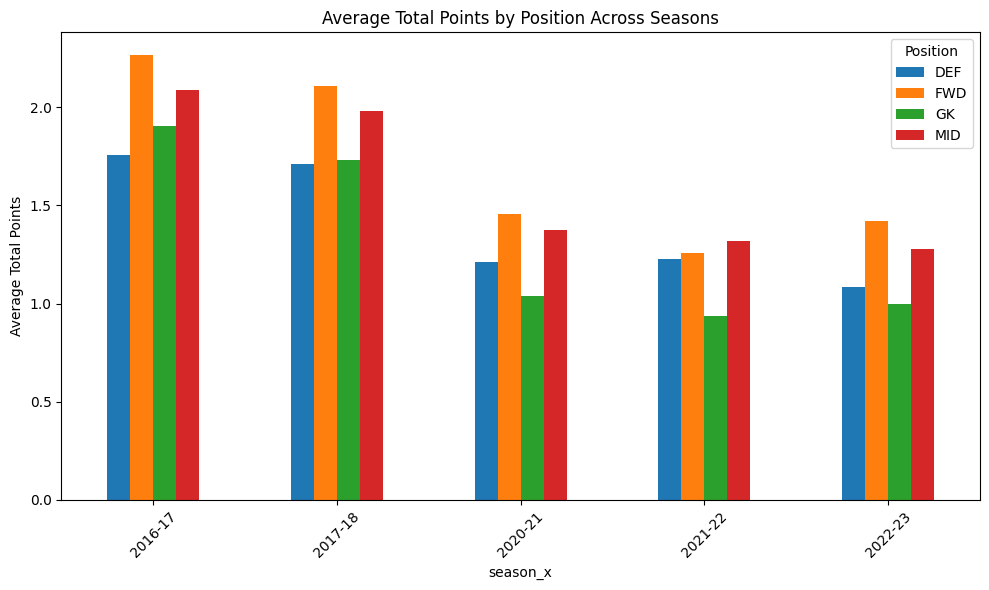

In [67]:
ans.plot(kind='bar', figsize=(10,6))
plt.ylabel('Average Total Points')
plt.title('Average Total Points by Position Across Seasons')
plt.xticks(rotation=45)
plt.legend(title='Position')
plt.tight_layout()
plt.show()

$\text{Question B)}$ Using the form feature, how did the performance of the top five players evolve across gameweeks during the 2022–23 FPL season? <br>

Answer: We see that performance fluctuates quite significantly with peaks and dips, so not increasing linearly which makes sense because no players form increases every match they have good and bad matches.

We get the best 5 players in terms of total points for the season 22/23, then for those 5 players we plot a graph that shows how their form changes from gameweek to gameweek om the 22/23 season

- We notice here that the form does not start from zero because we opted to make the form carry from season to season

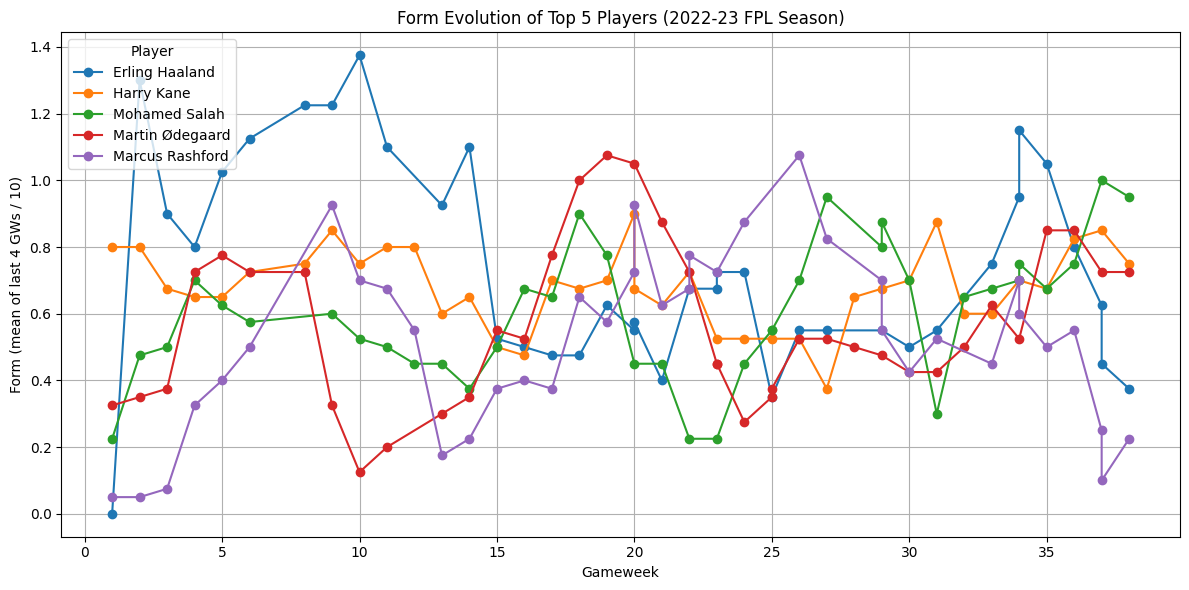

In [68]:
# Get top 5 players by total points in 2022-23 season
top5_codes = (
    fpl_copy[fpl_copy['season_x'] == '2022-23']
    .groupby('code')['total_points']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter data for these players in 2022-23
top5_df = fpl_copy[(fpl_copy['season_x'] == '2022-23') & (fpl_copy['code'].isin(top5_codes))]

# Get player names for legend
code_to_name = (
    top5_df.groupby('code')['name']
    .first()
    .to_dict()
)

plt.figure(figsize=(12, 6))
for code in top5_codes:
    player_data = top5_df[top5_df['code'] == code]
    plt.plot(player_data['GW'], player_data['form'], marker='o', label=code_to_name[code])

plt.xlabel('Gameweek')
plt.ylabel('Form (mean of last 4 GWs / 10)')
plt.title('Form Evolution of Top 5 Players (2022-23 FPL Season)')
plt.legend(title='Player')
plt.grid(True)
plt.tight_layout()
plt.show()

$\text{Question B.1)}$ Are the top players in form the same top players with the highest total points?

Answer: No, in the last gameweeks some new players had a better form than the top point scoring players, probably because the highest total scoring players have been more consistent but in the last gameweeks didn't really perform well (this happens as well when the team had already won the league, before the last some gameweeks and some players might slack or get benched to rest) <br> 

However, we see that Salah and Kane also had a good form towards the end of the season.

Here we choose to show the form at the last gameweek rather than a sum of all entries in that season

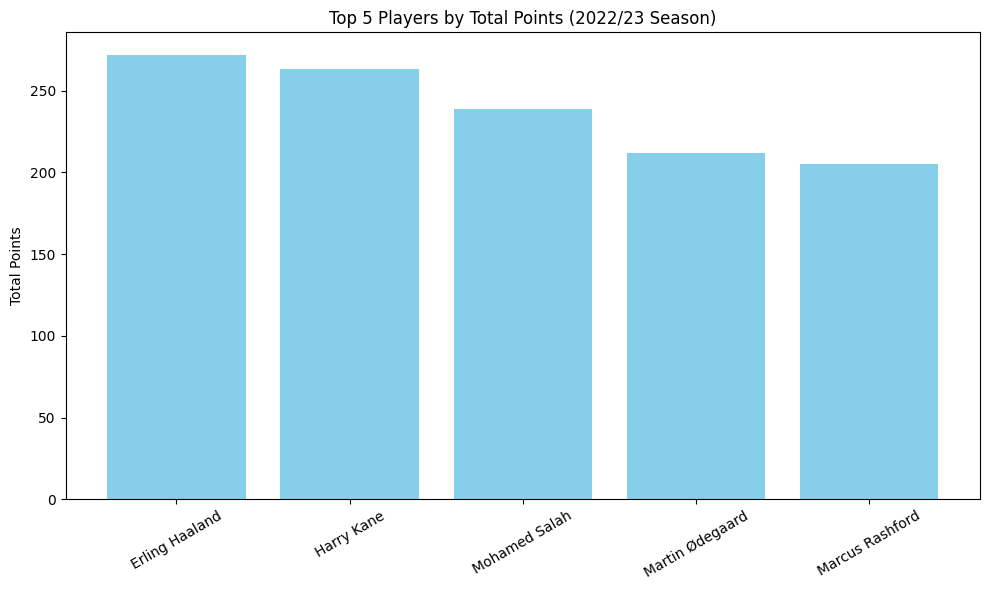

In [69]:
# Get top 5 players by total points in 2022-23 season
top5_total_codes = (
    fpl_copy[fpl_copy['season_x'] == '2022-23']
    .groupby('code')['total_points']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_total_df = (
    fpl_copy[(fpl_copy['season_x'] == '2022-23') & (fpl_copy['code'].isin(top5_total_codes))]
    .groupby(['code', 'name'], as_index=False)['total_points']
    .sum()
    .sort_values('total_points', ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(top5_total_df['name'], top5_total_df['total_points'], color='skyblue')
plt.ylabel('Total Points')
plt.title('Top 5 Players by Total Points (2022/23 Season)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

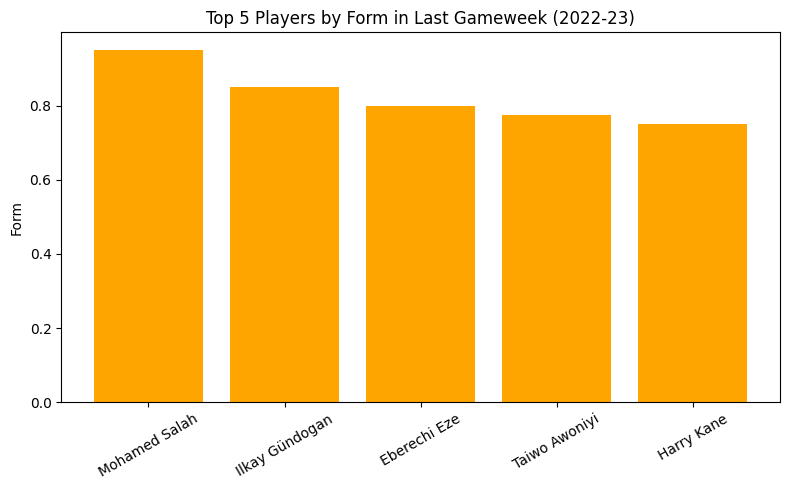

In [70]:
# Get the last gameweek number for 2022-23 season
last_gw = fpl_copy[fpl_copy['season_x'] == '2022-23']['GW'].max()

# Filter for last gameweek
last_gw_df = fpl_copy[(fpl_copy['season_x'] == '2022-23') & (fpl_copy['GW'] == last_gw)]

# Get top 5 players by form in the last gameweek
top5_last_gw_form = last_gw_df.nlargest(5, 'form')[['name', 'form']]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(top5_last_gw_form['name'], top5_last_gw_form['form'], color='orange')
plt.ylabel('Form')
plt.title('Top 5 Players by Form in Last Gameweek (2022-23)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Prediction and Inference Models

In [71]:
fpl_model = fpl_copy.dropna(subset=['upcoming_total_points']).copy()

For the next two models we are going to test different hidden layer configurations of NNs --> Trial and Test

## Model 1 ( player related-ish features with 3 hidden layers (128, 64, 32) )

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [73]:
features = [
    'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]

X = fpl_model[features]
y = fpl_model['upcoming_total_points']


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import r2_score


In [76]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [77]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [79]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - MAE: 1.2367 - MSE: 4.8896 - RMSE: 2.2112 - loss: 4.8896 - val_MAE: 1.3564 - val_MSE: 4.8821 - val_RMSE: 2.2096 - val_loss: 4.8821
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2344 - MSE: 4.8018 - RMSE: 2.1913 - loss: 4.8018 - val_MAE: 1.2424 - val_MSE: 4.8774 - val_RMSE: 2.2085 - val_loss: 4.8774
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2320 - MSE: 4.7905 - RMSE: 2.1887 - loss: 4.7905 - val_MAE: 1.3001 - val_MSE: 4.8828 - val_RMSE: 2.2097 - val_loss: 4.8828
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2314 - MSE: 4.7807 - RMSE: 2.1865 - loss: 4.7807 - val_MAE: 1.2689 - val_MSE: 4.8512 - val_RMSE: 2.2025 - val_loss: 4.8512
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2315 - MSE: 4.7841 - RMSE: 2.1873 - loss: 4.7841 - val_MAE: 1.2698 - val_MSE: 4.8429 - val_RMSE: 2.2007 - val_loss: 4.8429
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2319 - 

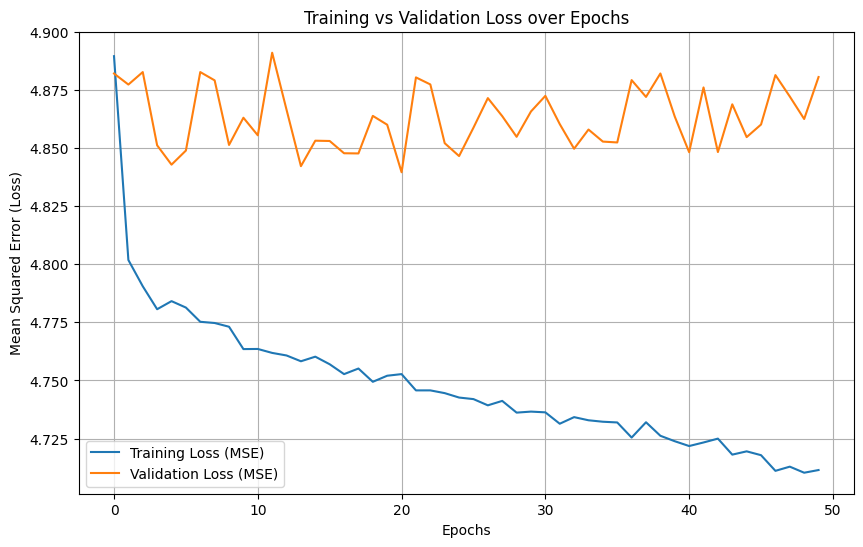

In [80]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

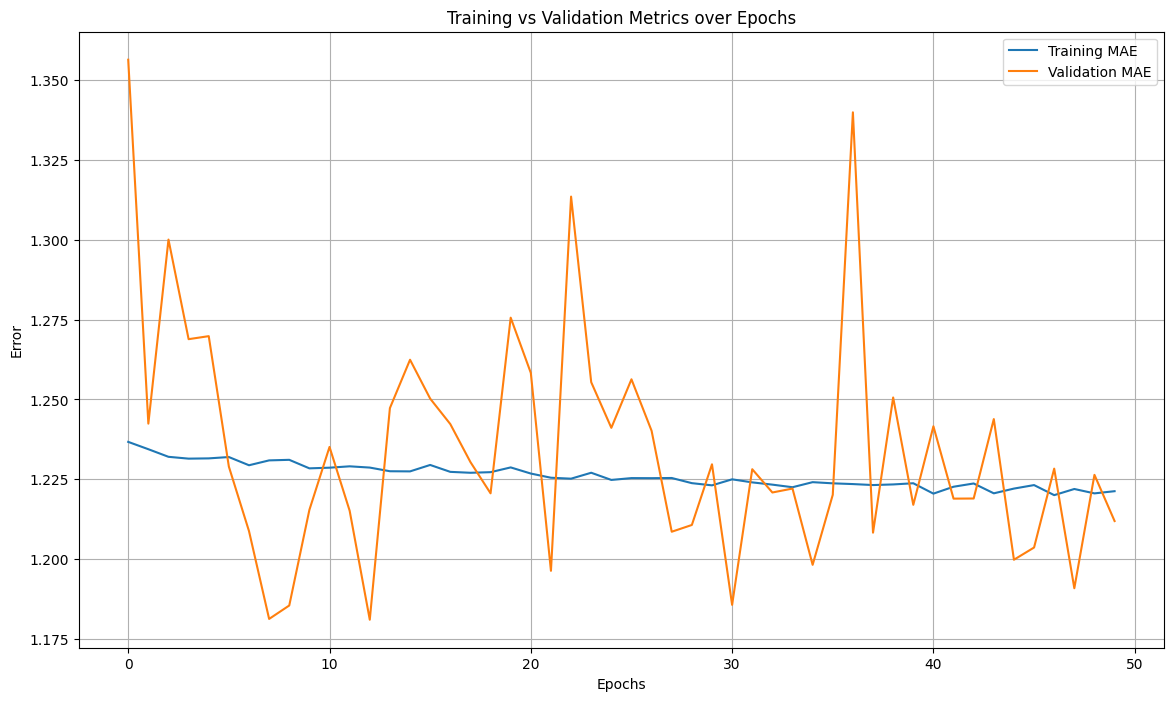

In [81]:
metrics = ['MAE']

plt.figure(figsize=(14,8))

for metric in ['MAE']:
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')

plt.title('Training vs Validation Metrics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

In [82]:
results = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MAE: {results[1]:.3f}")
print(f"MSE: {results[2]:.3f}")
print(f"RMSE: {results[3]:.3f}")

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

MAE: 1.218
MSE: 4.802
RMSE: 2.191
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step
R²: 0.258


## Model 2 ( player related-ish features with 2 hidden layers (64, 32) )

In [83]:
features_2 = [
    'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]
X = fpl_model[features_2]
y = fpl_model['upcoming_total_points']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
model_2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [86]:
model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [87]:
history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2388 - MSE: 4.8996 - RMSE: 2.2135 - loss: 4.8996 - val_MAE: 1.2357 - val_MSE: 4.8559 - val_RMSE: 2.2036 - val_loss: 4.8559
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2329 - MSE: 4.8017 - RMSE: 2.1913 - loss: 4.8017 - val_MAE: 1.1998 - val_MSE: 4.8874 - val_RMSE: 2.2107 - val_loss: 4.8874
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2310 - MSE: 4.7919 - RMSE: 2.1890 - loss: 4.7919 - val_MAE: 1.2388 - val_MSE: 4.8706 - val_RMSE: 2.2069 - val_loss: 4.8706
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2299 - MSE: 4.7810 - RMSE: 2.1866 - loss: 4.7810 - val_MAE: 1.2407 - val_MSE: 4.8642 - val_RMSE: 2.2055 - val_loss: 4.8642
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2312 - MSE: 4.7807 - RMSE: 2.1865 - loss: 4.7807 - val_MAE: 1.2040 - val_MSE: 4.8597 - val_RMSE: 2.2045 - val_loss: 4.8597
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2298 - 

In [88]:
results = model_2.evaluate(X_test_scaled, y_test, verbose=0)
print(f"MAE: {results[1]:.3f}")
print(f"MSE: {results[2]:.3f}")
print(f"RMSE: {results[3]:.3f}")

y_pred = model_2.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

MAE: 1.249
MSE: 4.754
RMSE: 2.180
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step
R²: 0.266


## Not Scaled same as model 2 but without scaling just to explore the effect

In [89]:
features_3 = [
    'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]
X = fpl_model[features_2]
y = fpl_model['upcoming_total_points']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
model_3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [92]:
model_3.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [93]:
history_3 = model_3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2776 - MSE: 5.1226 - RMSE: 2.2633 - loss: 5.1226 - val_MAE: 1.4057 - val_MSE: 5.3971 - val_RMSE: 2.3232 - val_loss: 5.3971
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2646 - MSE: 4.8987 - RMSE: 2.2133 - loss: 4.8987 - val_MAE: 1.2639 - val_MSE: 4.9018 - val_RMSE: 2.2140 - val_loss: 4.9018
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2594 - MSE: 4.8714 - RMSE: 2.2071 - loss: 4.8714 - val_MAE: 1.2009 - val_MSE: 5.0141 - val_RMSE: 2.2392 - val_loss: 5.0141
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2387 - MSE: 4.8411 - RMSE: 2.2003 - loss: 4.8411 - val_MAE: 1.2668 - val_MSE: 4.8698 - val_RMSE: 2.2068 - val_loss: 4.8698
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2332 - MSE: 4.8185 - RMSE: 2.1951 - loss: 4.8185 - val_MAE: 1.2498 - val_MSE: 4.8660 - val_RMSE: 2.2059 - val_loss: 4.8660
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2326 - 

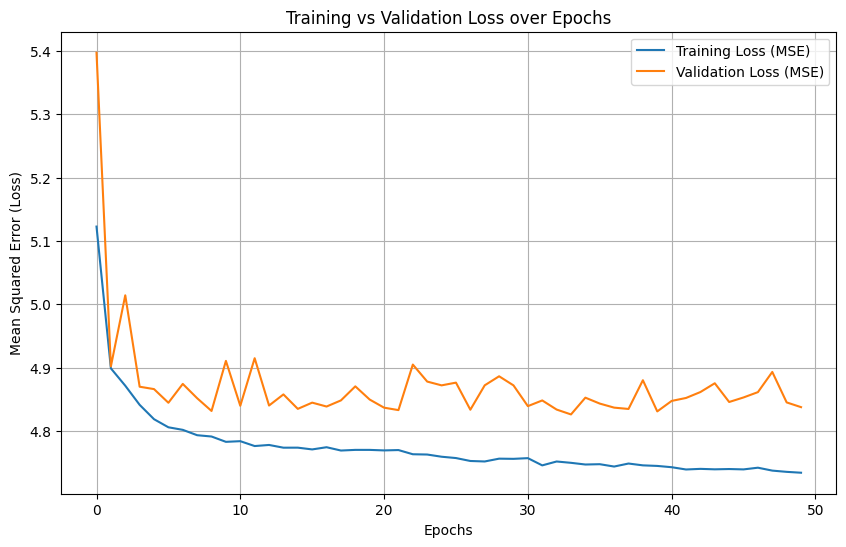

In [94]:
plt.figure(figsize=(10,6))
plt.plot(history_3.history['loss'], label='Training Loss (MSE)')
plt.plot(history_3.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
results = model_3.evaluate(X_test, y_test, verbose=0)
print(f"MAE: {results[1]:.3f}")
print(f"MSE: {results[2]:.3f}")
print(f"RMSE: {results[3]:.3f}")

y_pred = model_3.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

MAE: 1.244
MSE: 4.746
RMSE: 2.179
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step
R²: 0.109


### Trial-and-error (empirical):
The above two different trained models, is an example of a trial and error diecision, we were seeing whether there is an advantage to using a standard scalar to scale the values and indeed as can be seen no using it yielded a significantly worse $r^2$ 0.038 compared with 0.263

## Match Related Features Model

In [96]:
fpl_copy.tail()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
96164,2022-23,George Shelvey,GK,Nott'm Forest,0,0,0,0,0.0,749,375,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,7,Crystal Palace,0,0,0,0,38,0,600,1.0,1.0,0.0,0,52,78,26,40,0,0,38,0,0,1,0,450197,31,4,NaN,0.000,5,0.842338,1.331321,-0.488983
96165,2022-23,Oliver Hammond,MID,Nott'm Forest,0,0,0,0,0.0,553,375,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,7,Crystal Palace,0,0,0,0,38,0,4117,1.0,1.0,0.0,0,78,114,36,42,0,0,38,0,0,0,1,475492,31,4,NaN,0.000,5,0.842338,1.331321,-0.488983
96166,2022-23,Loïc Badé,DEF,Nott'm Forest,0,0,0,0,0.0,621,375,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,7,Crystal Palace,0,0,0,0,38,0,2270,1.0,1.0,0.0,0,-6,0,6,45,0,0,38,1,0,0,0,500267,31,4,NaN,0.000,5,0.842338,1.331321,-0.488983
96167,2022-23,Danilo dos Santos de Oliveira,MID,Nott'm Forest,0,0,0,0,0.0,703,375,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,7,Crystal Palace,0,0,0,0,38,0,19926,1.0,1.0,0.0,0,-1944,2329,4273,45,0,0,38,0,0,0,1,513046,31,4,NaN,0.625,5,0.842338,1.331321,-0.488983
96168,2022-23,Dale Taylor,FWD,Nott'm Forest,0,0,0,0,0.0,666,375,0,0,0.0,0.0,2023-05-28T15:30:00Z,0,7,Crystal Palace,0,0,0,0,38,0,1249,1.0,1.0,0.0,0,-13,0,13,45,0,0,38,0,1,0,0,524069,31,4,NaN,0.000,5,0.842338,1.331321,-0.488983


In [97]:
features_match = [
    'goals_scored', 'minutes', 'assists', 'clean_sheets', 'was_home', 'strength_difference', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'saves', 'goals_conceded', 'goals_scored'
    # , 'value',
    # 'was_home', 'team_x_global_code', 'opponent_team_global_code', 'form', "team_strength", "opponent_strength"
]
X = fpl_model[features_match]
y = fpl_model['upcoming_total_points']

In [98]:
X_train_match, X_test_match, y_train_match, y_test_match = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled_match = scaler.fit_transform(X_train_match)
X_test_scaled_match = scaler.transform(X_test_match)

In [99]:
model_match = Sequential([
    Input(shape=(X_train_match.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [100]:
model_match.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [101]:
history_match = model_match.fit(
    X_train_scaled_match, y_train_match,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - MAE: 1.2971 - MSE: 5.0360 - RMSE: 2.2441 - loss: 5.0360 - val_MAE: 1.3482 - val_MSE: 5.0447 - val_RMSE: 2.2460 - val_loss: 5.0447
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2869 - MSE: 4.9549 - RMSE: 2.2260 - loss: 4.9549 - val_MAE: 1.2205 - val_MSE: 5.0667 - val_RMSE: 2.2509 - val_loss: 5.0667
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2858 - MSE: 4.9399 - RMSE: 2.2226 - loss: 4.9399 - val_MAE: 1.2827 - val_MSE: 4.9898 - val_RMSE: 2.2338 - val_loss: 4.9898
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2831 - MSE: 4.9239 - RMSE: 2.2190 - loss: 4.9239 - val_MAE: 1.3216 - val_MSE: 4.9778 - val_RMSE: 2.2311 - val_loss: 4.9778
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2847 - MSE: 4.9176 - RMSE: 2.2176 - loss: 4.9176 - val_MAE: 1.3222 - val_MSE: 4.9853 - val_RMSE: 2.2328 - val_loss: 4.9853
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2853 - 

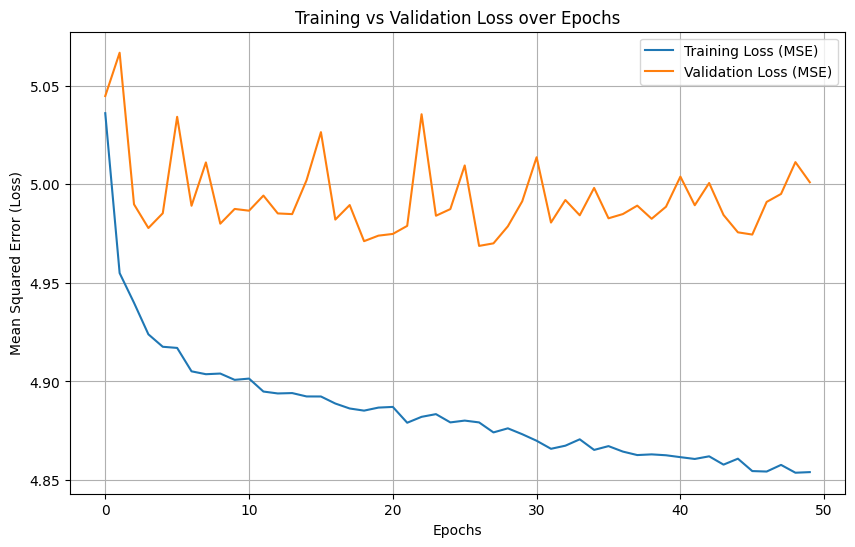

In [102]:
plt.figure(figsize=(10,6))
plt.plot(history_match.history['loss'], label='Training Loss (MSE)')
plt.plot(history_match.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
results_match = model_match.evaluate(X_test_scaled_match, y_test_match, verbose=0)
print(f"MAE: {results_match[1]:.3f}")
print(f"MSE: {results_match[2]:.3f}")
print(f"RMSE: {results_match[3]:.3f}")

y_pred_match = model_match.predict(X_test_scaled_match)
r2_match = r2_score(y_test_match, y_pred_match)
print(f"R²: {r2_match:.3f}")

MAE: 1.290
MSE: 4.905
RMSE: 2.215
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
R²: 0.242


### Shap and Lime

Here we will see weach features contribute most do a good result and do the same for player related features model then do a third model that combines the good from both worlds

PermutationExplainer explainer: 1001it [01:53,  8.73it/s]                          
C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\4240563056.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_match).head(1000),


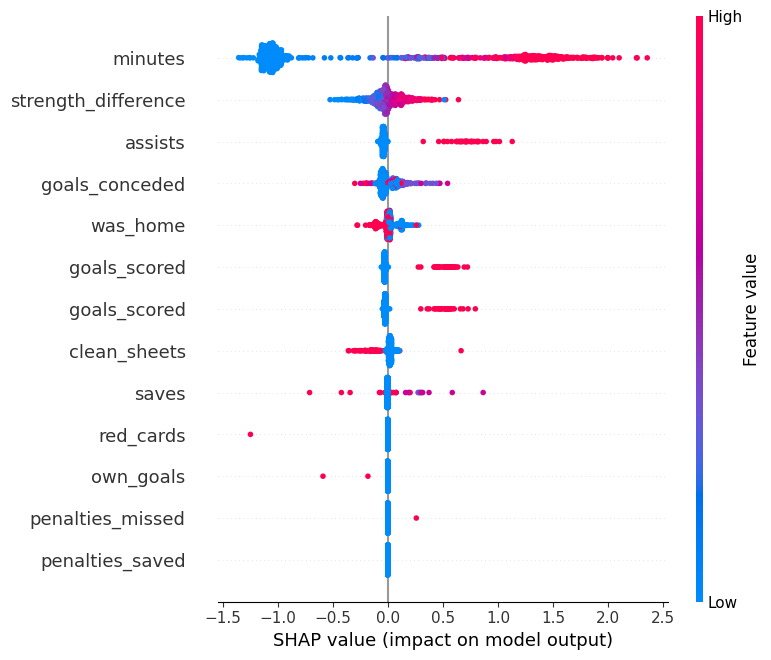

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\4240563056.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_match).head(1000),


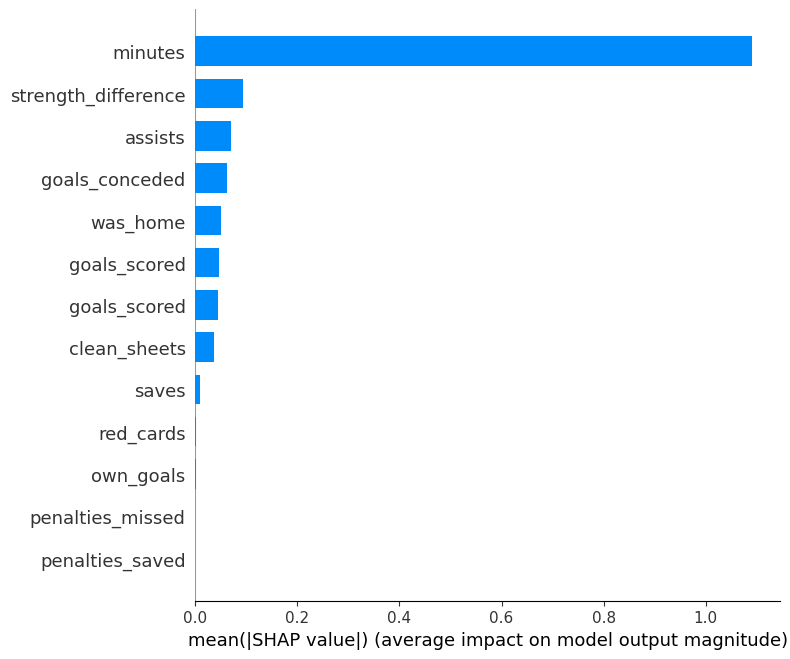

In [ ]:
# Use Explainer -> finds the best XAI model to use for your model
# Use a small background (reference) set to speed up explanations
# If X_train_scaled is a DataFrame, shap.sample will preserve columns
background = shap.sample(pd.DataFrame(X_train_scaled_match), 100, random_state=42)

# Let SHAP pick the best algorithm for your Keras model
explainer = shap.Explainer(model_match, background)
shap_values = explainer(pd.DataFrame(X_test_scaled_match).head(1000))

# Global summary
shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_match).head(1000),
                  feature_names=features_match)

shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_match).head(1000),
                  feature_names=features_match, plot_type='bar')

# Local explanation
i = 0
shap.initjs()
# Easiest way with the new API
shap.plots.force(shap_values[i], feature_names=features_match)


In [105]:
from lime import lime_tabular
from IPython.display import HTML

explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_scaled_match,
    feature_names=features_match,
    discretize_continuous=True,
    mode='regression'
)

# Create explanation for instance i
i = 100
exp = explainer_lime.explain_instance(
    X_train_scaled_match[i],
    lambda x: model_match.predict(x),
    num_features=len(features_match)
)



# Display the explanation
display(HTML(exp.as_html()))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step


## Player Related Features Model

In [106]:
fpl_model.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,pos_DEF,pos_FWD,pos_GK,pos_MID,code,team_x_global_code,opponent_team_global_code,upcoming_total_points,form,season_x_code,team_strength,opponent_strength,strength_difference
0,2016-17,Theo Walcott,MID,Arsenal,0,0,21,0,20.0,13,8,4,1,10.5,46.6,2016-08-14T15:00:00Z,90,9,Liverpool,0,1,0,0,1,0,48930,4.0,3.0,38.0,5,0,0,0,75,1,0,1,0,0,0,1,20467,0,8,3.0,0.0,1,NaN,NaN,0.0
1,2016-17,Mesut Özil,MID,Arsenal,0,0,0,0,0.0,14,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,179727,4.0,3.0,0.0,0,0,0,0,95,1,0,1,0,0,0,1,37605,0,8,1.0,0.0,1,NaN,NaN,0.0
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,1,0,1,0,0,0,1,41792,0,8,0.0,0.0,1,NaN,NaN,0.0
3,2016-17,Kieran Gibbs,DEF,Arsenal,0,0,0,0,0.0,7,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,22607,4.0,3.0,0.0,0,0,0,0,50,1,0,1,1,0,0,0,42427,0,8,0.0,0.0,1,NaN,NaN,0.0
4,2016-17,Olivier Giroud,FWD,Arsenal,0,0,0,0,0.0,25,8,0,0,0.0,0.0,2016-08-14T15:00:00Z,0,9,Liverpool,0,0,0,0,1,0,50997,4.0,3.0,0.0,0,0,0,0,90,1,0,1,0,1,0,0,44346,0,8,1.0,0.0,1,NaN,NaN,0.0


In [107]:
features_player = [
    'pos_GK', 'pos_DEF', 'pos_MID', 'pos_FWD', 'influence', 'creativity', 'threat', 'ict_index', 'form' , 'bps', 'value'
]
X = fpl_model[features_player]
y = fpl_model['upcoming_total_points']

In [108]:
X_train_player, X_test_player, y_train_player, y_test_player = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled_player = scaler.fit_transform(X_train_player)
X_test_scaled_player = scaler.transform(X_test_player)

In [109]:
model_player = Sequential([
    Input(shape=(X_train_player.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [110]:
model_player.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

In [111]:
history_player = model_player.fit(
    X_train_scaled_player, y_train_player,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - MAE: 1.2455 - MSE: 4.8127 - RMSE: 2.1938 - loss: 4.8127 - val_MAE: 1.2352 - val_MSE: 4.8011 - val_RMSE: 2.1911 - val_loss: 4.8011
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2298 - MSE: 4.7290 - RMSE: 2.1746 - loss: 4.7290 - val_MAE: 1.2295 - val_MSE: 4.7891 - val_RMSE: 2.1884 - val_loss: 4.7891
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2248 - MSE: 4.7149 - RMSE: 2.1714 - loss: 4.7149 - val_MAE: 1.2962 - val_MSE: 4.7930 - val_RMSE: 2.1893 - val_loss: 4.7930
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2216 - MSE: 4.7076 - RMSE: 2.1697 - loss: 4.7076 - val_MAE: 1.2363 - val_MSE: 4.7671 - val_RMSE: 2.1834 - val_loss: 4.7671
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2206 - MSE: 4.6900 - RMSE: 2.1656 - loss: 4.6900 - val_MAE: 1.2508 - val_MSE: 4.7667 - val_RMSE: 2.1833 - val_loss: 4.7667
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - MAE: 1.2196 - 

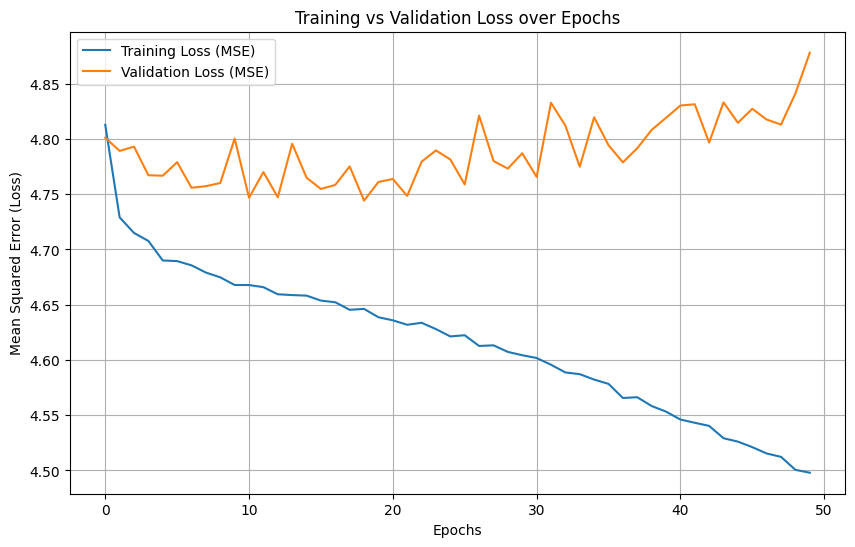

In [112]:
plt.figure(figsize=(10,6))
plt.plot(history_player.history['loss'], label='Training Loss (MSE)')
plt.plot(history_player.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [113]:
results_player = model_player.evaluate(X_test_scaled_player, y_test_player, verbose=0)
print(f"MAE: {results_player[1]:.3f}")
print(f"MSE: {results_player[2]:.3f}")
print(f"RMSE: {results_player[3]:.3f}")

y_pred_player = model_player.predict(X_test_scaled_player)
r2_player = r2_score(y_test_player, y_pred_player)
print(f"R²: {r2_player:.3f}")

MAE: 1.236
MSE: 4.821
RMSE: 2.196
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
R²: 0.255


### Shap And Lime

#### Shap

PermutationExplainer explainer: 1001it [01:52,  8.14it/s]                          
C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\3556700663.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_player).head(1000),


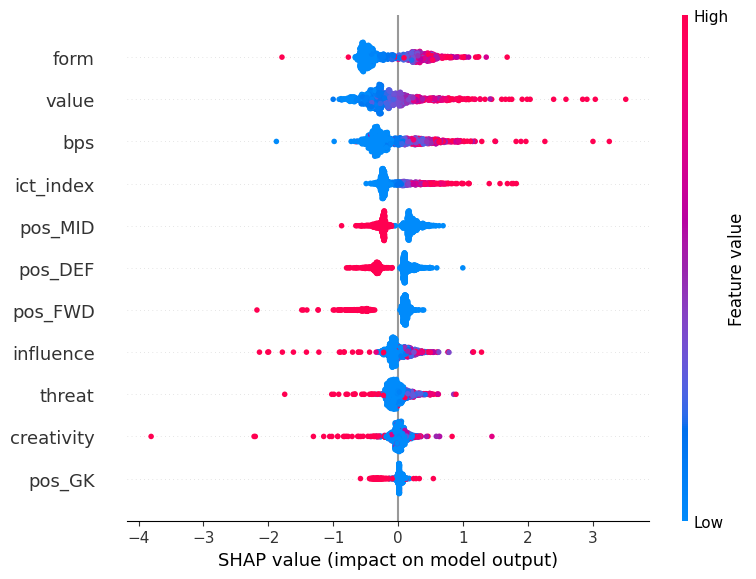

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\3556700663.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_player).head(1000),


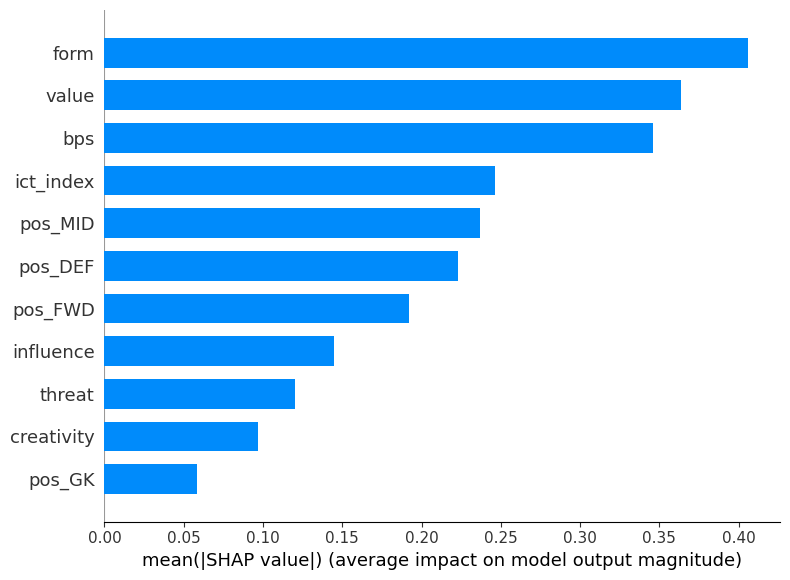

In [114]:
# Use Explainer -> finds the best XAI model to use for your model
# Use a small background (reference) set to speed up explanations
# If X_train_scaled is a DataFrame, shap.sample will preserve columns
background = shap.sample(pd.DataFrame(X_train_scaled_player), 100, random_state=42)

# Let SHAP pick the best algorithm for your Keras model
explainer = shap.Explainer(model_player, background)
shap_values = explainer(pd.DataFrame(X_test_scaled_player).head(1000))

# Global summary
shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_player).head(1000),
                  feature_names=features_player)

shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_player).head(1000),
                  feature_names=features_player, plot_type='bar')

# Local explanation
i = 0
shap.initjs()
# Easiest way with the new API
shap.plots.force(shap_values[i], feature_names=features_player)


#### Lime

In [115]:
from lime import lime_tabular
from IPython.display import HTML

explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_scaled_player,
    feature_names=features_player,
    discretize_continuous=True,
    mode='regression'
)

# Create explanation for instance i
i = 100
exp = explainer_lime.explain_instance(
    X_train_scaled_player[i],
    lambda x: model_player.predict(x),
    num_features=len(features_player)
)

# Display the explanation
display(HTML(exp.as_html()))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


## Hypothesis Driven Step: Train a model with the best features from both player related and match related --> we hypothesize this should improve performance

In [116]:
features_combined = [
    'form', 'bps', 'value', 'ict_index', 'minutes', 'assists', 'goals_conceded', 'goals_scored', 'strength_difference'
]
X = fpl_model[features_combined]
y = fpl_model['upcoming_total_points']

In [117]:
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled_combined = scaler.fit_transform(X_train_combined)
X_test_scaled_combined = scaler.transform(X_test_combined)

In [118]:
model_combined = Sequential([
    Input(shape=(X_train_combined.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='linear')
    ])

In [119]:
model_combined.compile(
    optimizer='adam',
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='MAE'),
        keras.metrics.MeanSquaredError(name='MSE'),
        keras.metrics.RootMeanSquaredError(name='RMSE')
    ]
)

Here we try to use early stopping to try to reduce overfitting as much as we can

In [120]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_combined = model_combined.fit(
    X_train_scaled_combined, y_train_combined,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - MAE: 1.2289 - MSE: 4.7838 - RMSE: 2.1872 - loss: 4.7838 - val_MAE: 1.2673 - val_MSE: 4.8038 - val_RMSE: 2.1918 - val_loss: 4.8038
Epoch 2/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2199 - MSE: 4.7198 - RMSE: 2.1725 - loss: 4.7198 - val_MAE: 1.2544 - val_MSE: 4.7600 - val_RMSE: 2.1818 - val_loss: 4.7600
Epoch 3/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2167 - MSE: 4.6985 - RMSE: 2.1676 - loss: 4.6985 - val_MAE: 1.2309 - val_MSE: 4.7455 - val_RMSE: 2.1784 - val_loss: 4.7455
Epoch 4/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2160 - MSE: 4.6898 - RMSE: 2.1656 - loss: 4.6898 - val_MAE: 1.2576 - val_MSE: 4.7508 - val_RMSE: 2.1796 - val_loss: 4.7508
Epoch 5/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2162 - MSE: 4.6816 - RMSE: 2.1637 - loss: 4.6816 - val_MAE: 1.1963 - val_MSE: 4.7719 - val_RMSE: 2.1845 - val_loss: 4.7719
Epoch 6/50
1899/1899 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - MAE: 1.2138 - 

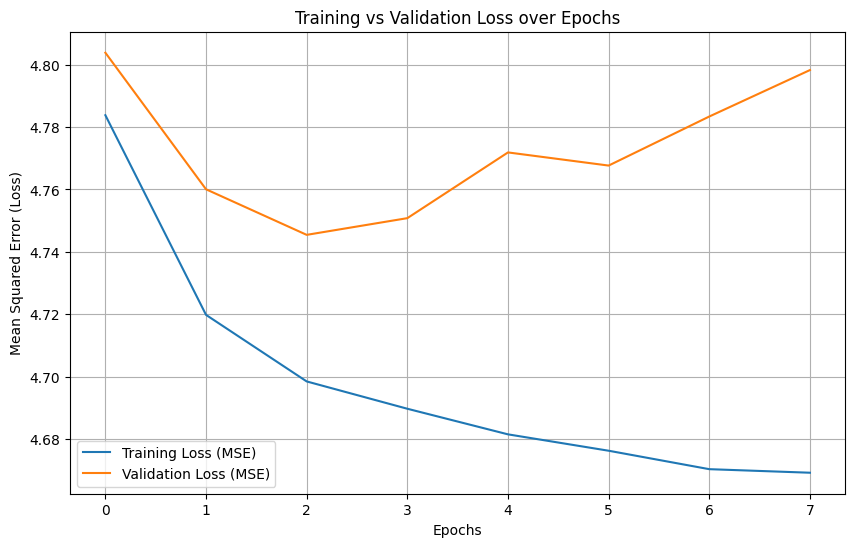

In [121]:
plt.figure(figsize=(10,6))
plt.plot(history_combined.history['loss'], label='Training Loss (MSE)')
plt.plot(history_combined.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [122]:
results_combined = model_combined.evaluate(X_test_scaled_combined, y_test_combined, verbose=0)
print(f"MAE: {results_combined[1]:.3f}")
print(f"MSE: {results_combined[2]:.3f}")
print(f"RMSE: {results_combined[3]:.3f}")

y_pred_combined = model_combined.predict(X_test_scaled_combined)
r2_combined = r2_score(y_test_combined, y_pred_combined)
print(f"R²: {r2_combined:.3f}")

MAE: 1.236
MSE: 4.672
RMSE: 2.161
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
R²: 0.278


### Shap

ExactExplainer explainer: 1001it [00:46, 17.13it/s]                         
C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\449369354.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_combined).head(1000),


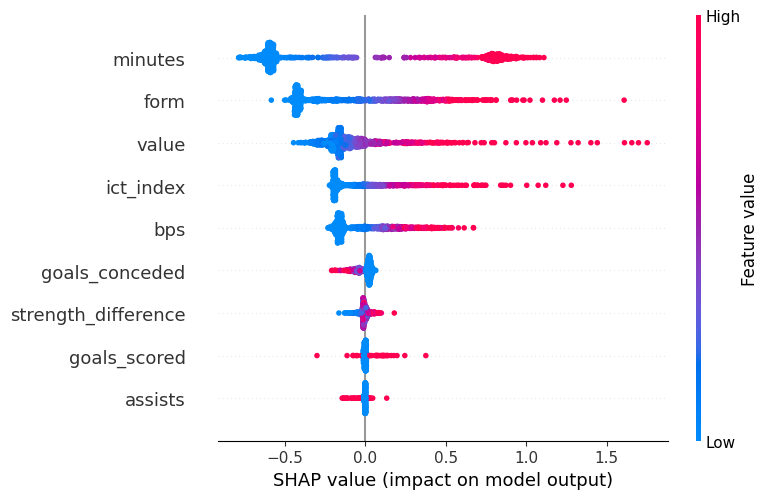

C:\Users\Seif El Din Nassar\AppData\Local\Temp\ipykernel_26820\449369354.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_combined).head(1000),


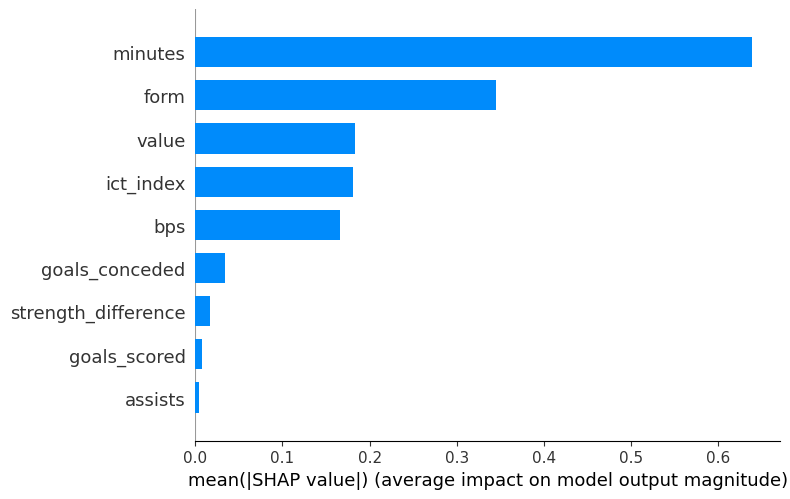

In [123]:
# Use Explainer -> finds the best XAI model to use for your model
# Use a small background (reference) set to speed up explanations
# If X_train_scaled is a DataFrame, shap.sample will preserve columns
background = shap.sample(pd.DataFrame(X_train_scaled_combined), 100, random_state=42)

# Let SHAP pick the best algorithm for your Keras model
explainer = shap.Explainer(model_combined, background)
shap_values = explainer(pd.DataFrame(X_test_scaled_combined).head(1000))

# Global summary
shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_combined).head(1000),
                  feature_names=features_combined)

shap.summary_plot(shap_values.values, pd.DataFrame(X_test_scaled_combined).head(1000),
                  feature_names=features_combined, plot_type='bar')

# Local explanation
i = 0
shap.initjs()
# Easiest way with the new API
shap.plots.force(shap_values[i], feature_names=features_combined)


### Lime

In [124]:
from lime import lime_tabular
from IPython.display import HTML

explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_scaled_combined,
    feature_names=features_combined,
    discretize_continuous=True,
    mode='regression'
)

# Create explanation for instance i
i = 100
exp = explainer_lime.explain_instance(
    X_train_scaled_combined[i],
    lambda x: model_combined.predict(x),
    num_features=len(features_combined)
)

# Display the explanation
display(HTML(exp.as_html()))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


## Inference Function

In [126]:
def predict_upcoming_points(raw_input, scaler, model, feature_list=None):
    """
    Accepts either a full row (pd.Series) or a dict with many columns,
    extracts the needed features (internal default or provided feature_list),
    scales and predicts using the provided scaler and model.
    """
    # If a dict is passed, convert to Series for consistent access
    if isinstance(raw_input, dict):
        row = pd.Series(raw_input)
    else:
        row = raw_input  # assume pd.Series or similar

    # Default feature set (used if feature_list is not provided)
    default_features = [
        'form',
        'bps',
        'value',
        'ict_index',
        'minutes',
        'assists',
        'goals_conceded',
        'goals_scored',
        'strength_difference'
    ]

    features = feature_list if feature_list is not None else default_features

    def _get_value(feat_name):
        # handle position one-hot features like pos_GK, pos_DEF, ...
        if feat_name.startswith('pos_'):
            target_pos = feat_name.split('_', 1)[1]
            pos_val = row.get('position', None)
            if pd.isna(pos_val):
                return 0
            return 1 if str(pos_val).upper() == target_pos else 0

        # direct mapping for common columns
        val = row.get(feat_name, None)
        # Some columns may be named differently (opp_team_name vs opponent_team) - fallback not added here
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 0
        # Convert booleans to ints and ensure numeric types are floats
        if isinstance(val, (bool, np.bool_)):
            return int(val)
        try:
            return float(val)
        except Exception:
            # For non-numeric fields (e.g., team names), return 0 by default
            return 0

    # Build input vector in the same order as features
    input_vector = [_get_value(f) for f in features]

    # Scale and predict
    input_scaled = scaler.transform([input_vector])
    pred = model.predict(input_scaled)[0][0]

    # Use the original row value for name (not _get_value which coerces to float)
    player_name = row.get('name', None)
    if player_name is None or pd.isna(player_name):
        player_name = "<unknown>"
    else:
        player_name = str(player_name)

    return f"Predicted upcoming total points: {pred:.2f}. This means the player {player_name} is expected to score approximately {pred:.2f} points in the next gameweek."

# Example usage with the combined model
example_input_1 = {
    'name': 'Mohamed Salah',
    'form': 0.75,
    'bps': 60,
    'value': 120,
    'ict_index': 10.5,
    'minutes': 90,
    'assists': 1,
    'goals_conceded': 0,
    'goals_scored': 2,
    'strength_difference': 0.5
}

example_input_2 = {
    'name': 'Harry Kane',
    'form': 0.25,
    'bps': 30,
    'value': 90,
    'ict_index': 5.0,
    'minutes': 45,
    'assists': 0,
    'goals_conceded': 2,
    'goals_scored': 0,
    'strength_difference': -0.3
}

print(predict_upcoming_points(example_input_1, scaler, model_combined, features_combined))
print(predict_upcoming_points(example_input_2, scaler, model_combined, features_combined))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted upcoming total points: 6.29. This means the player Mohamed Salah is expected to score approximately 6.29 points in the next gameweek.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted upcoming total points: 3.44. This means the player Harry Kane is expected to score approximately 3.44 points in the next gameweek.


c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
